# House Price Prediction Using MLP Regression with PyTorch


## Phase 1 - Import Library, Config, Random Seed


In [1]:
import sys
from pathlib import Path

sys.path.append("/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression")
from processing_own_phase.phase_1_import_library import (
    ProjectConfig,
    display_path_collection,
    run_phase_1_import_library,
)

config = run_phase_1_import_library(
    ProjectConfig(
        batch_size=64,
        epochs=150,
        learning_rate=0.0005,
        hidden_units=(64,),
        dropout=0.0,
        weight_decay=0.0,
        loss_function="mse",
        huber_delta=1.0,
        gradient_clip_norm=5.0,
    )
)


## Phase 2 - Data Collection and Early Split
### Link data kangle: https://www.kaggle.com/datasets/harlfoxem/housesalesprediction?select=kc_house_data.csv
## Dataset Description

Bộ dữ liệu được sử dụng là **House Sales in King County, USA** từ Kaggle.  
Dữ liệu chứa thông tin các căn nhà được bán tại King County, Washington, bao gồm khu vực Seattle, trong giai đoạn từ tháng 5/2014 đến tháng 5/2015.

Dataset có khoảng **21.613 mẫu dữ liệu** và **21 thuộc tính**.  
Biến mục tiêu của bài toán là **price**, tức giá bán của căn nhà.  
Các đặc trưng đầu vào bao gồm số phòng ngủ, số phòng tắm, diện tích nhà, diện tích đất, số tầng, tình trạng nhà, năm xây dựng, năm sửa chữa và vị trí địa lý.

Bộ dữ liệu này phù hợp cho bài toán **dự đoán giá nhà bằng mô hình hồi quy**, đặc biệt là Linear Regression, Random Forest Regression hoặc MLP Regression.


In [2]:
from processing_own_phase.phase_2_collection_split import (
    display_phase_2_split_summary,
    run_phase_2_collection_split,
)

raw_df, train_df, val_df, test_df = run_phase_2_collection_split(config)
split_summary = display_phase_2_split_summary(raw_df, train_df, val_df, test_df, config)


Dataset,Shape,Actual ratio,Purpose
Raw data,"(21863, 21)",100.00%,Full dataset before split
Train,"(17490, 21)",80.00%,Used to fit preprocessing and model
Validation,"(2186, 21)",10.00%,Used for tuning and early stopping
Test,"(2187, 21)",10.00%,Used only for final evaluation


## Phase 3 - Data Overview and EDA


### Split summary

,split,rows,columns,missing_values,duplicate_rows
0,raw,21863,21,5169,250
1,train,17490,21,4118,145
2,validation,2186,21,514,5
3,test,2187,21,537,5


### train_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,952001765,20140707T000000,558000.000,2.000,-,1580.000,5750.000,1.000,0,0,5.000,6.000,790,790,1910.000,0,98116.000,47.567,-122.384,1580.000,5750.000
1,251620110,20140702T000000,2288000.000,4.000,2.500,4080.000,18362.000,2.000,0,2,4.000,11.000,4080,0,1983.000,0,98004.000,47.634,-122.214,4080.000,-
2,9521100795,20140623T000000,569000.000,4.000,2.000,1730.000,3884.000,1.000,0,0,5.000,7.000,1060,670,1924.000,0,98103.000,47.662,-122.349,1360.000,3563.000
3,8682310470,20150107T000000,445000.000,2.000,1.750,1440.000,4660.000,1.000,0,2,3.000,8.000,1440,0,2008.000,0,98053.000,47.709,-122.015,1680.000,4989.000
4,705730180,20141021T000000,339995.000,4.000,2.500,2180.000,5367.000,2.000,0,0,3.000,7.000,2180,0,2000.000,0,98038.000,47.377,-122.022,2180.000,5130.000


### train_df.info()

...

### Target distribution

,price
count,17490.000
mean,548411.476
std,448080.421
min,0.000
25%,321500.000
50%,450000.000
75%,649000.000
max,23850000.000


### Top correlations with price

,feature,correlation_with_price
0,sqft_living,0.591
1,grade,0.565
2,sqft_above,0.513
3,sqft_living15,0.487
4,bathrooms,0.393
5,view,0.344
6,sqft_basement,0.278
7,lat,0.259
8,waterfront,0.220
9,floors,0.211


price_distribution /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/eda/price_distribution.png


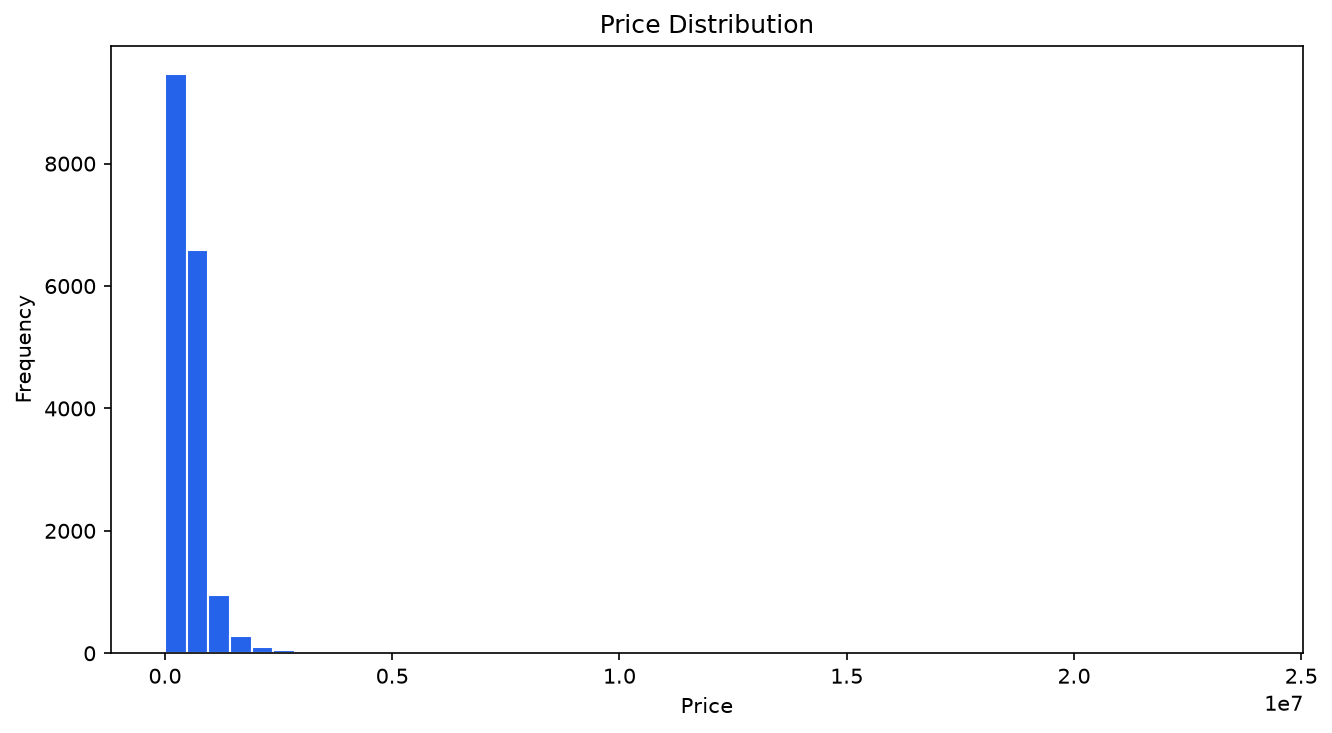

price_boxplot /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/eda/price_boxplot.png


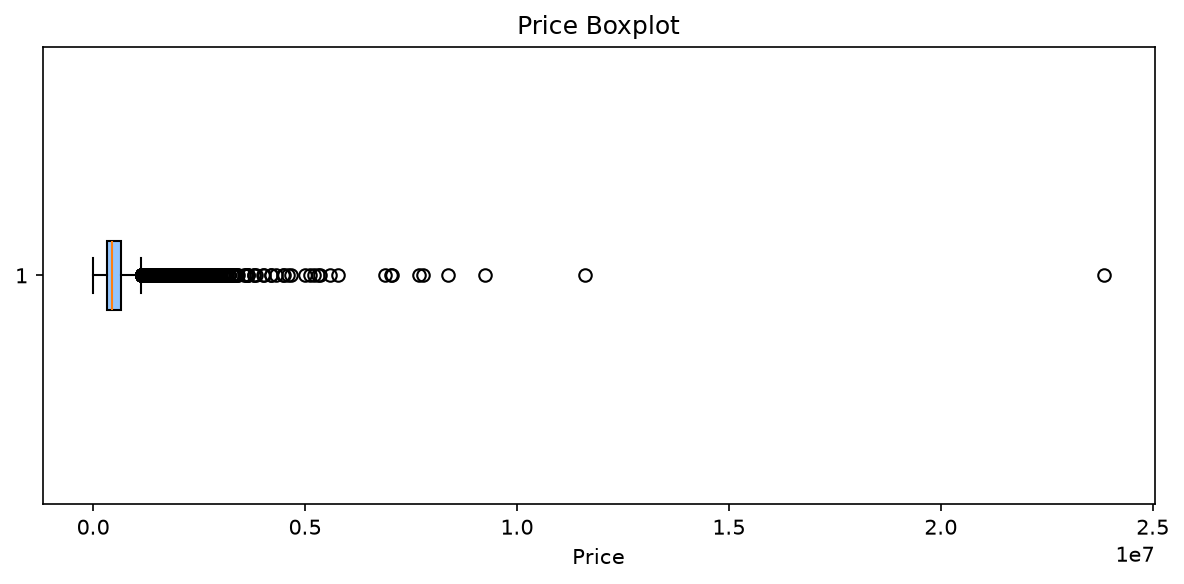

correlation_heatmap /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/eda/correlation_heatmap.png


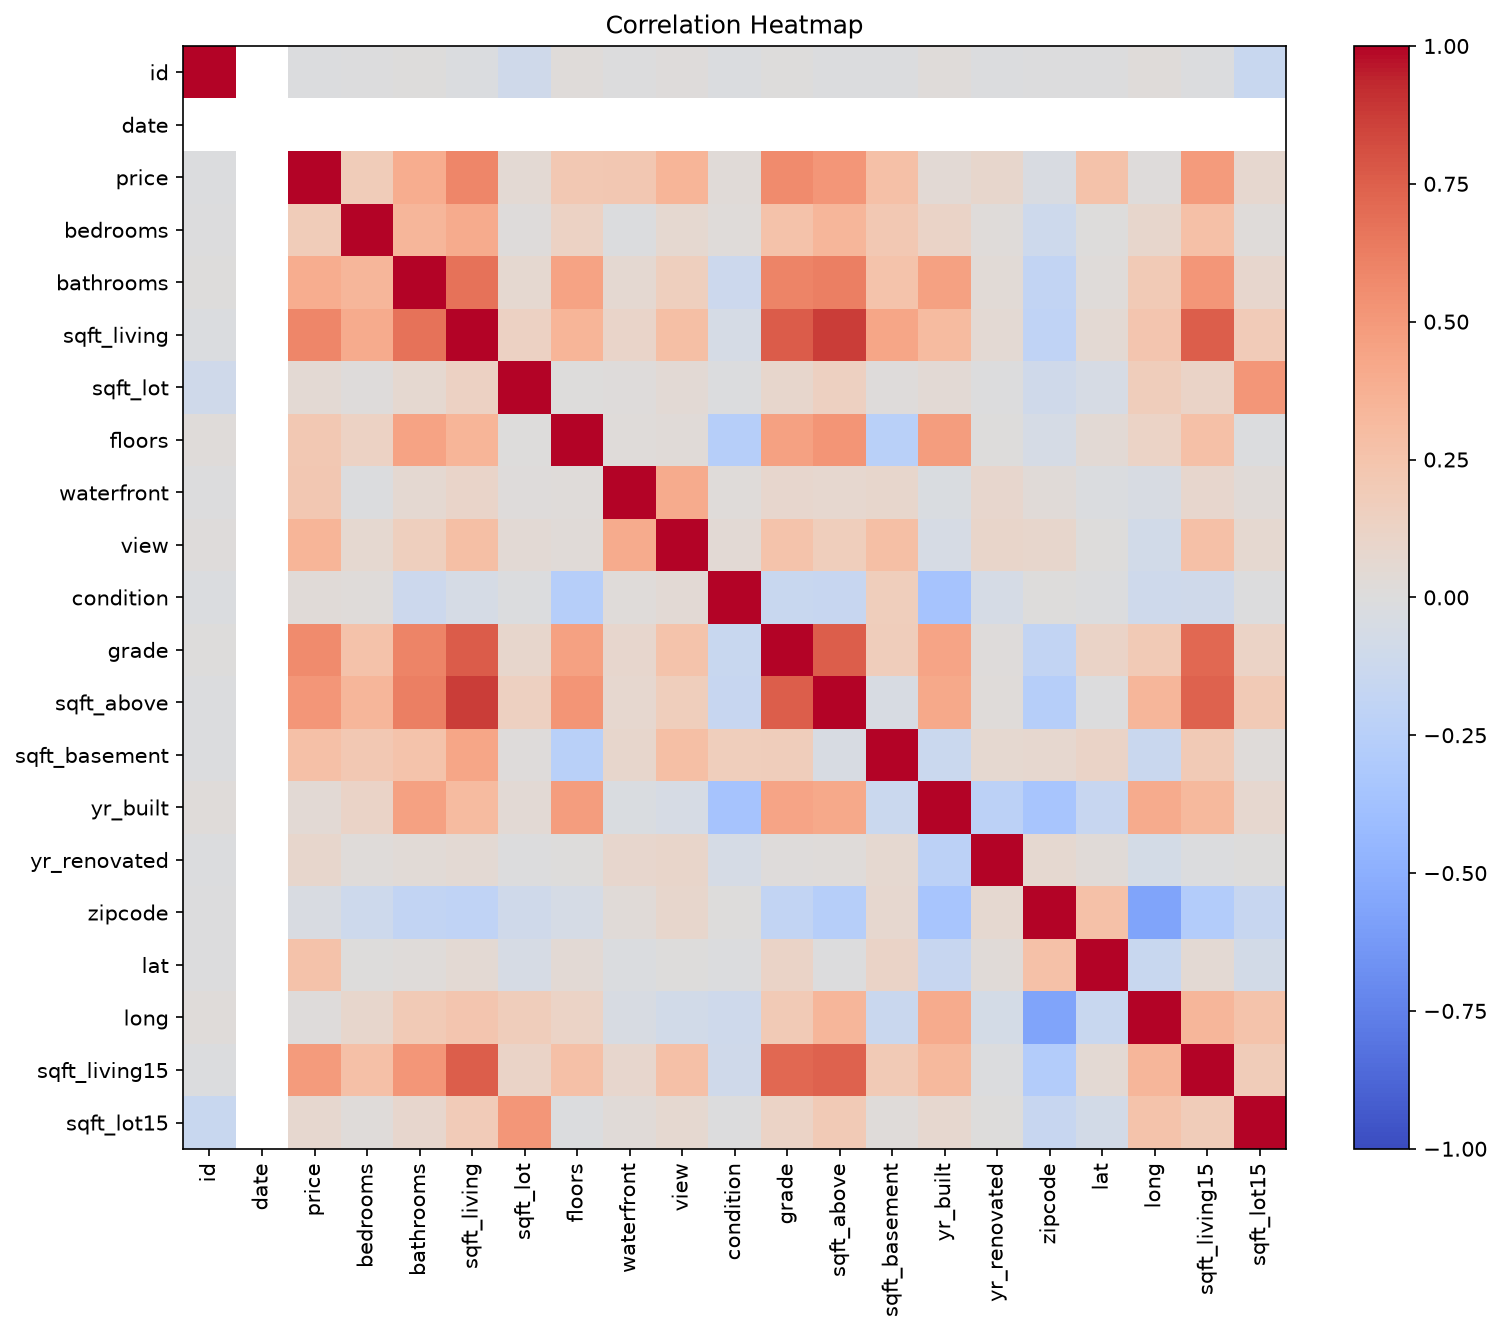

top_correlation_heatmap_annotated /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/eda/top_correlation_heatmap_annotated.png


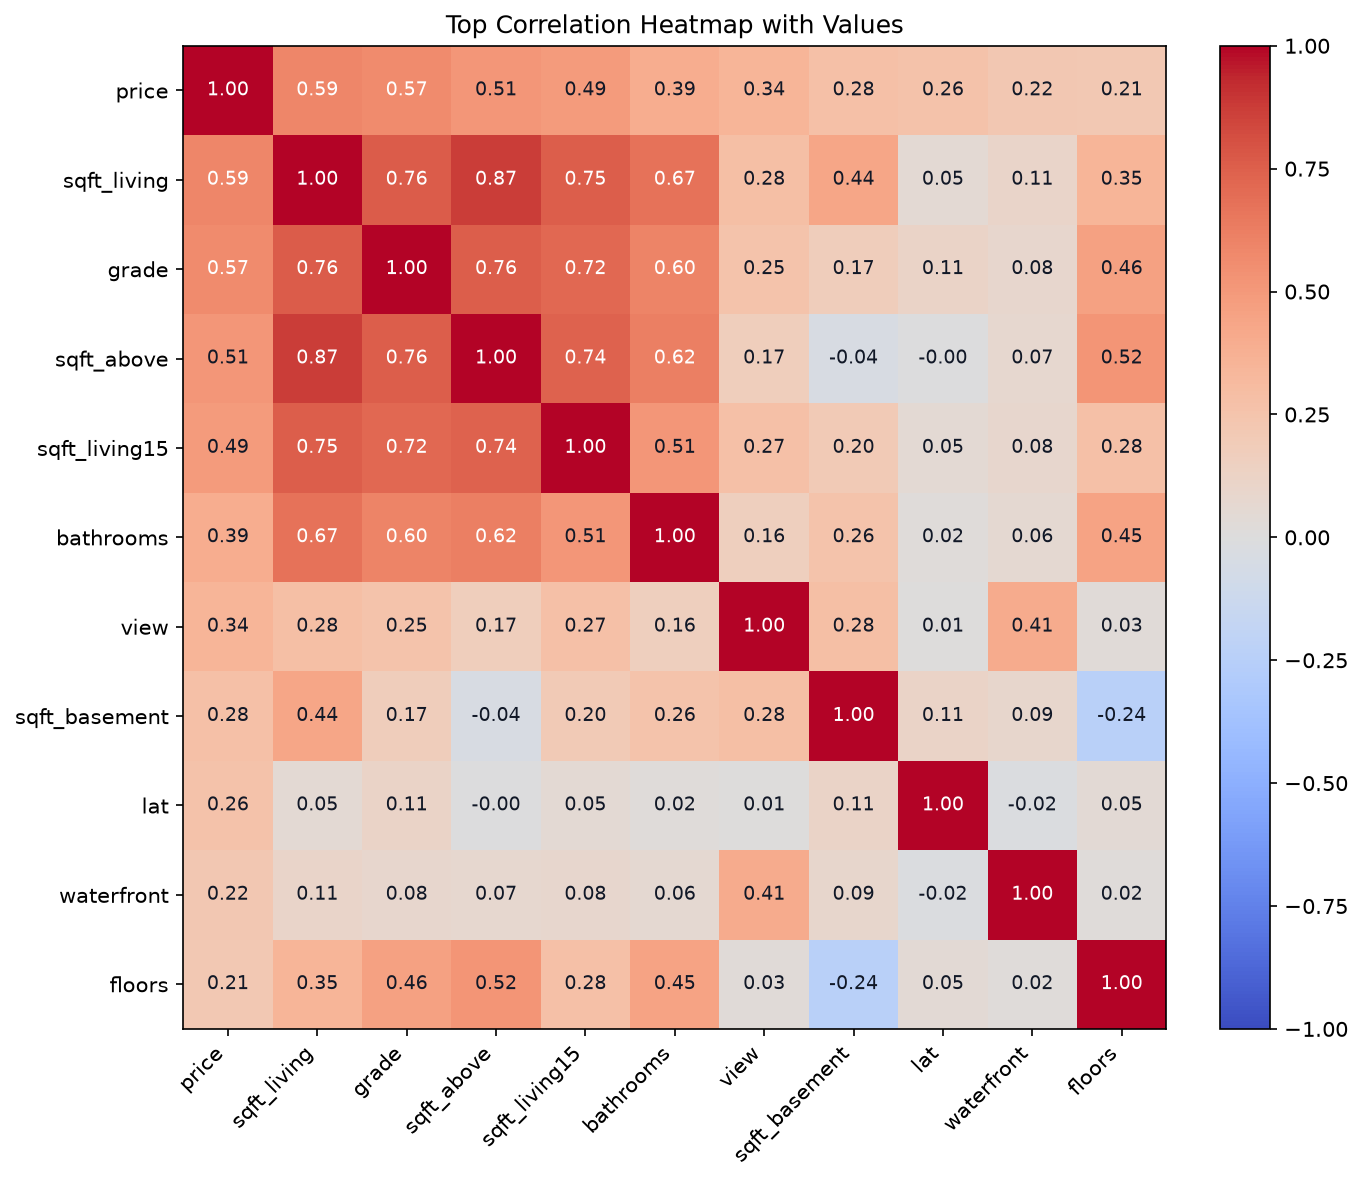

sqft_living_vs_price /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/eda/sqft_living_vs_price.png


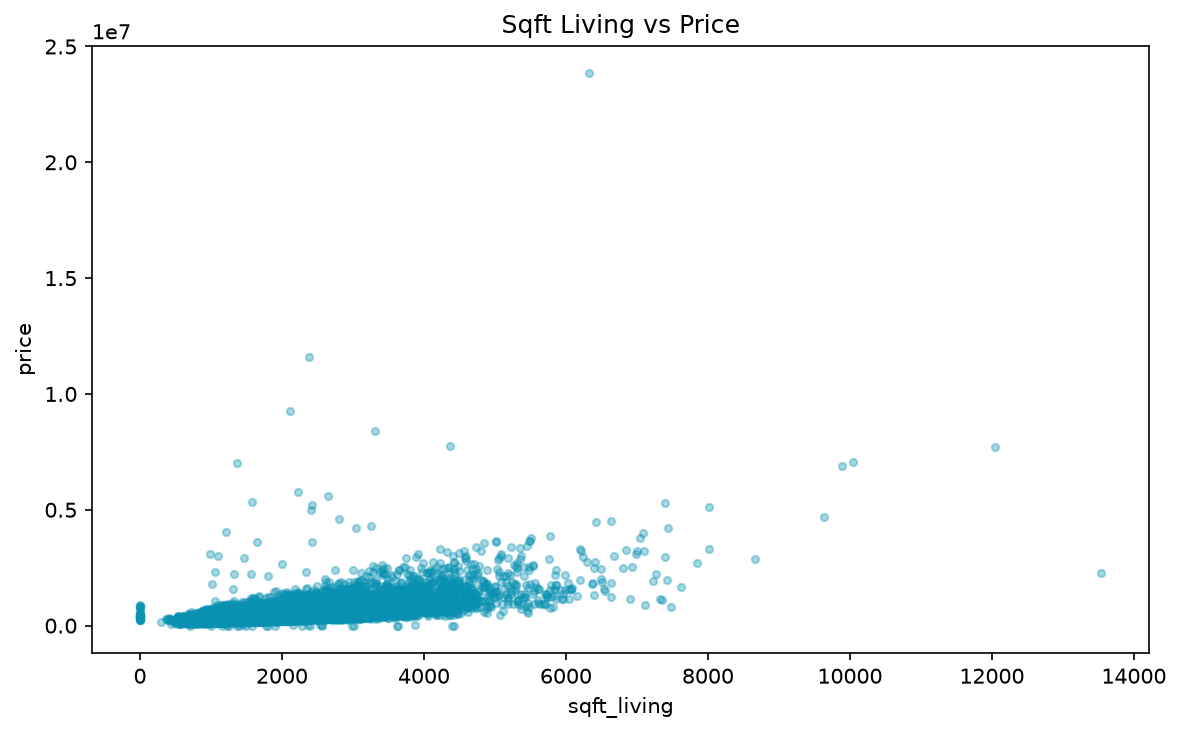

important_feature_histograms /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/eda/important_feature_histograms.png


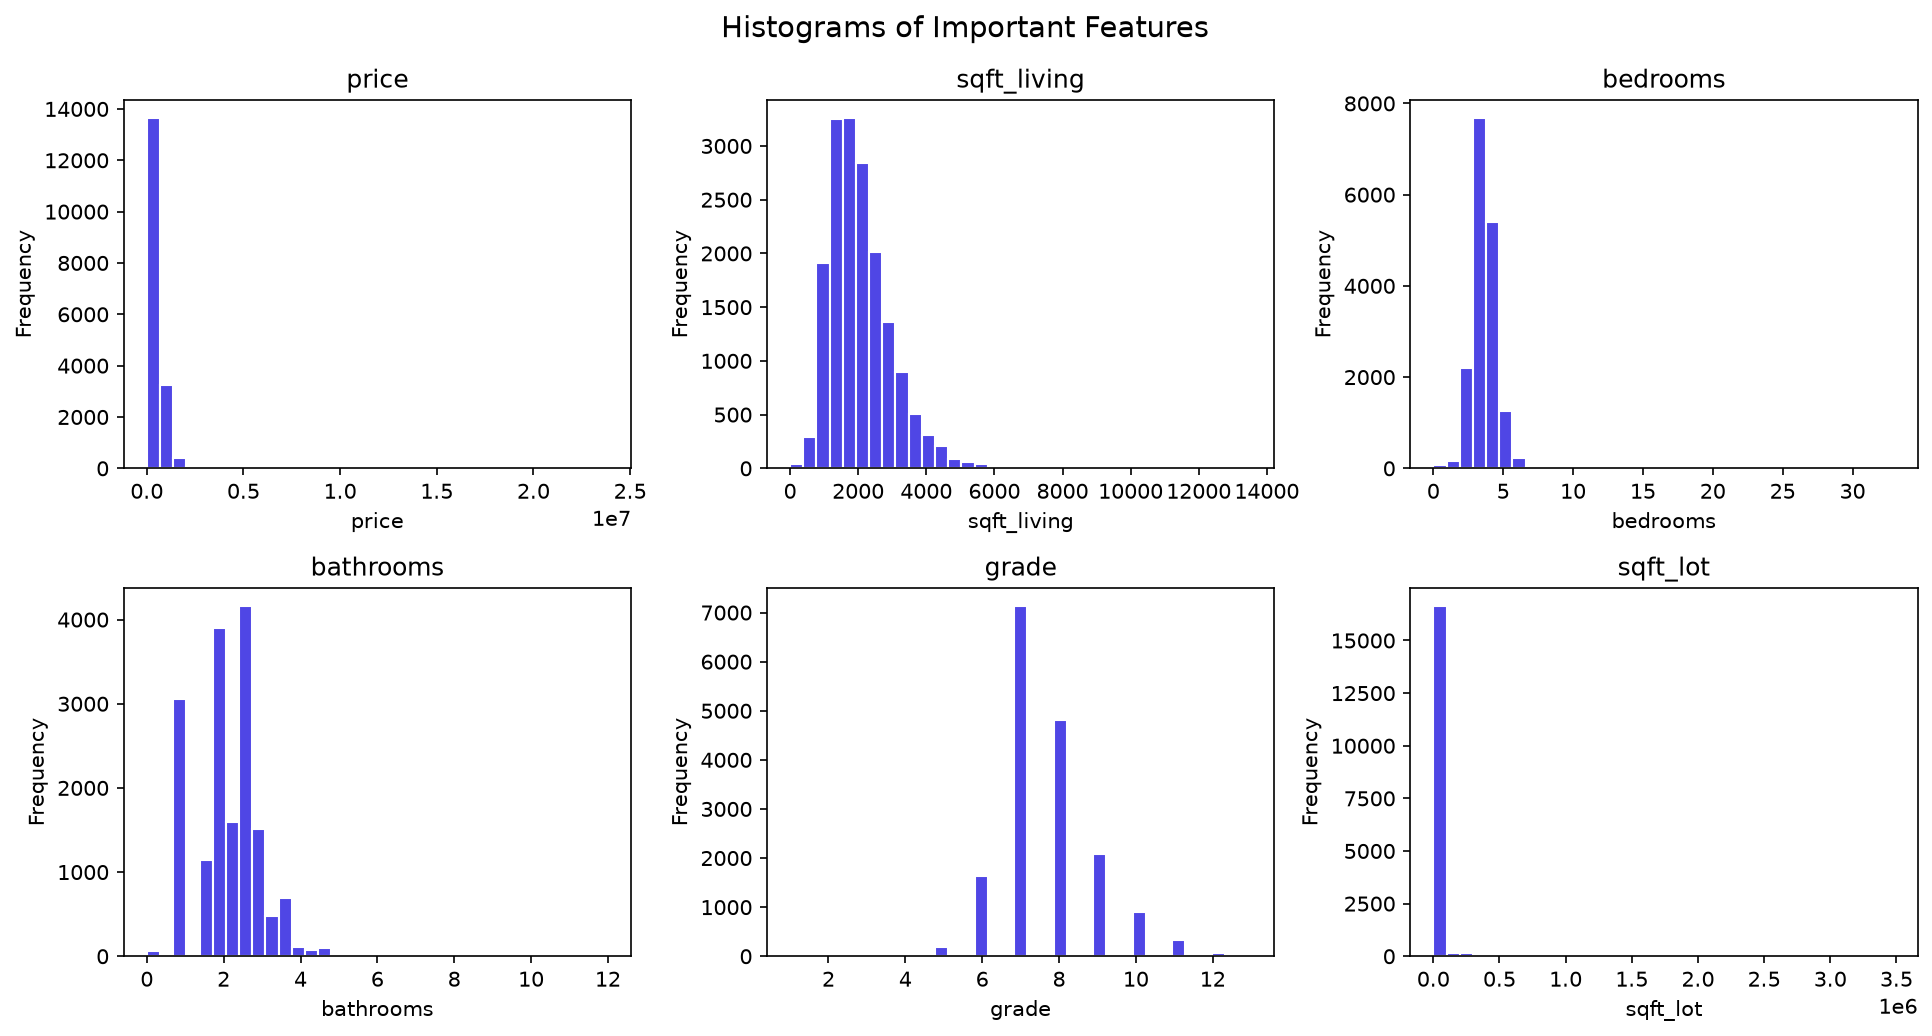

price_by_zipcode /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/eda/price_by_zipcode.png


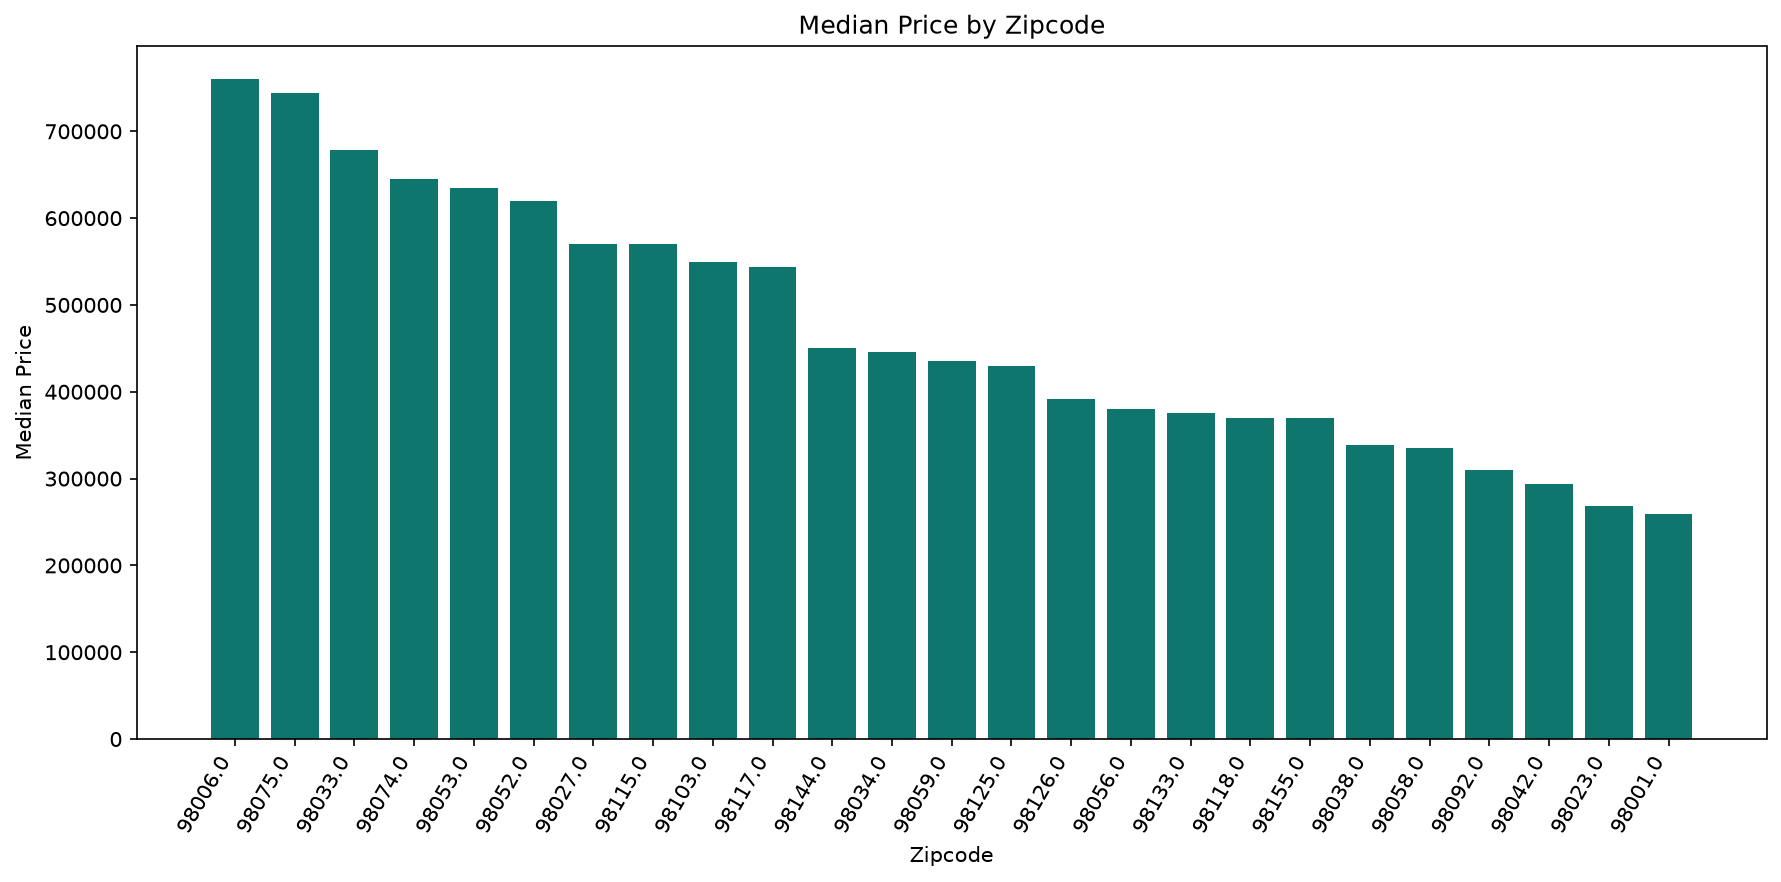

important_features_pairplot /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/eda/important_features_pairplot.png


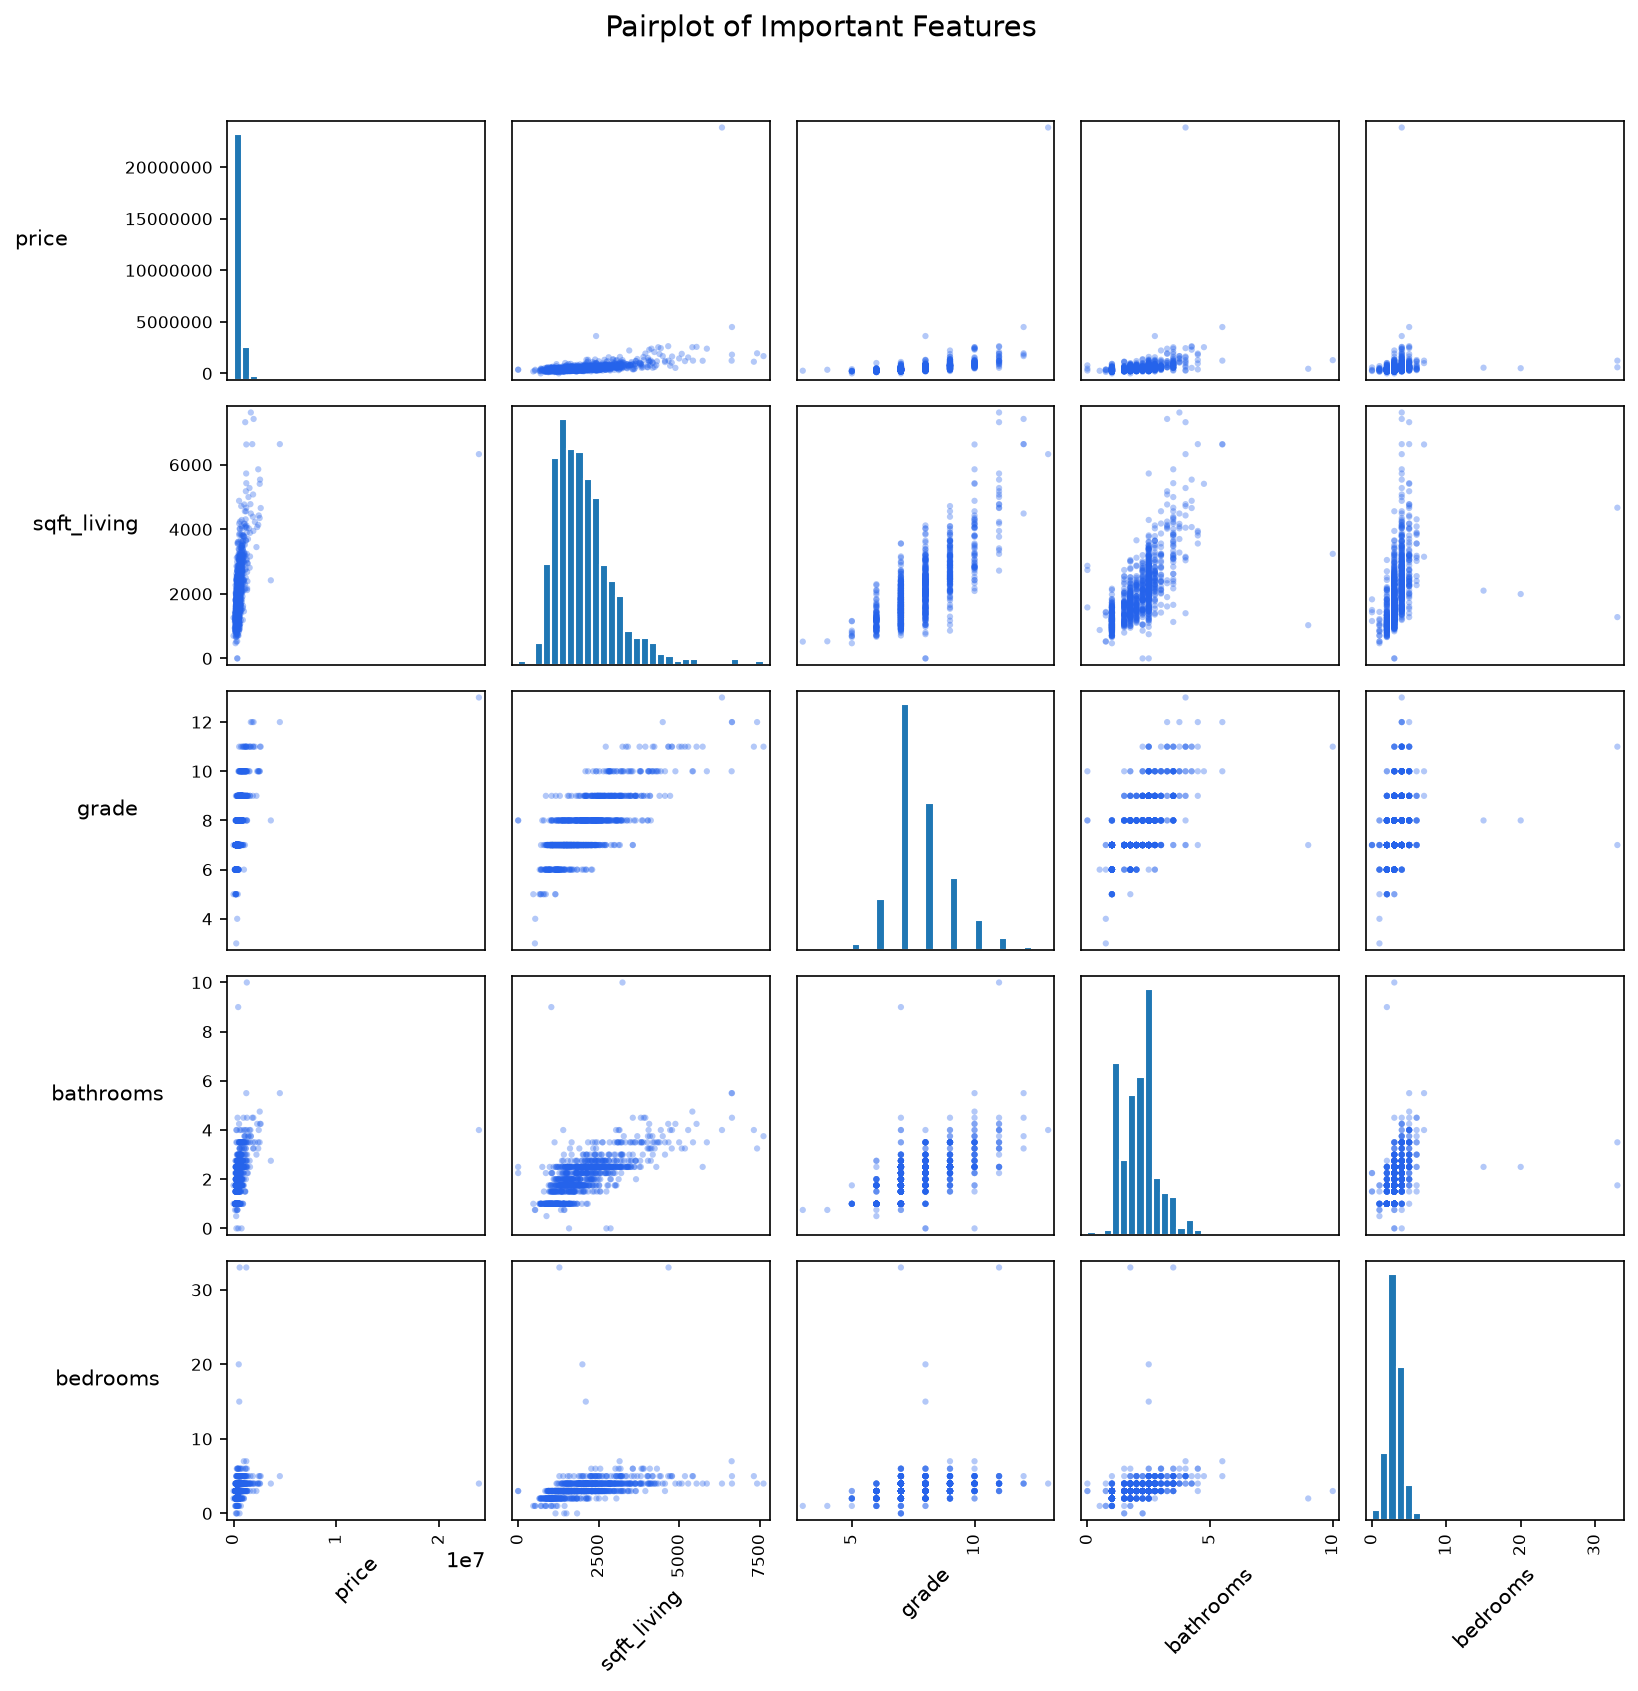

In [3]:
import importlib
from IPython.display import Markdown, display
import processing_own_phase.phase_3_data_overview_eda as phase_3

phase_3 = importlib.reload(phase_3)
overview_summary, eda_plot_paths = phase_3.run_phase_3_data_overview_eda(raw_df, train_df, val_df, test_df, config)

display(Markdown("### Split summary"))
display(phase_3.style_colored_table(overview_summary["split_table"], "Split summary"))

display(Markdown("### train_df.head()"))
display(phase_3.style_colored_table(overview_summary["train_head"], "First 5 training rows"))

display(Markdown("### train_df.info()"))
print(overview_summary["train_info"])

display(Markdown("### train_df.describe()"))
display(phase_3.style_colored_table(overview_summary["train_describe"], "Training descriptive statistics"))

display(Markdown("### Target distribution"))
display(phase_3.style_colored_table(overview_summary["target_distribution"], "Price target distribution"))

display(Markdown("### Top correlations with price"))
display(phase_3.style_colored_table(
    overview_summary["top_price_correlations"],
    "Top correlations with price",
    cmap="coolwarm",
    gradient_columns=["correlation_with_price"],
))

phase_3.display_path_collection(eda_plot_paths)


## Phase 4 - Data Cleaning


In [4]:
import importlib
from IPython.display import Markdown, display
import processing_own_phase.phase_4_data_cleaning as phase_4

phase_4 = importlib.reload(phase_4)
train_clean_df, val_clean_df, test_clean_df, cleaning_summary = phase_4.run_phase_4_data_cleaning(
    train_df,
    val_df,
    test_df,
    config.target_column,
)

display(Markdown("### Cleaning steps"))
display(phase_4.style_colored_table(cleaning_summary["cleaning_steps"], "Phase 4 cleaning decisions"))

display(Markdown("### Cleaning audit before/after"))
display(phase_4.style_colored_table(cleaning_summary["audit_table"], "Cleaning audit by split"))

display(Markdown("### Outlier check - flagged, not removed automatically"))
display(phase_4.style_colored_table(cleaning_summary["outlier_table"], "Outlier flags by split and feature"))

display(Markdown("### Clean training preview"))
display(phase_4.style_colored_table(train_clean_df.head(), "Cleaned training rows"))


### Cleaning steps

,step,phase_4_action,reason
0,Missing values,Standardize missing tokens to NaN; imputation is deferred to Phase 7,Imputer must be fit only on training data to prevent leakage
1,Duplicates,Drop duplicate rows inside each split,Duplicate records can bias model learning and evaluation
2,Outliers,"Flag IQR outliers for price, sqft_living, bedrooms, bathrooms",House-price outliers can be valid luxury/location-driven homes
3,Invalid values,Set impossible feature values to NaN; remove non-positive target rows,Later preprocessing handles NaN consistently
4,Remove unnecessary columns,Drop id column,Identifier has no predictive meaning for regression
5,Date processing,"Parse date and create sale_year, sale_month",Date parts are useful and easier for later feature engineering


### Cleaning audit before/after

,split,rows_before,rows_after,rows_removed,columns_before,columns_after,columns_removed,missing_before,missing_after,duplicate_rows_before,duplicate_rows_after,invalid_values_before,invalid_values_after,date_processed,sale_year_created,sale_month_created
0,train,17490,17338,152,23,22,id,4378,4596,145,0,253,0,True,True,True
1,validation,2186,2180,6,23,22,id,535,568,5,0,34,0,True,True,True
2,test,2187,2179,8,23,22,id,567,587,5,0,26,0,True,True,True


### Outlier check - flagged, not removed automatically

,split,feature,outlier_flags_before,outlier_flags_after,action
0,train,price,955,951,"Flag only, not removed automatically"
1,train,sqft_living,476,478,"Flag only, not removed automatically"
2,train,bedrooms,524,444,"Flag only, not removed automatically"
3,train,bathrooms,251,478,"Flag only, not removed automatically"
4,validation,price,112,112,"Flag only, not removed automatically"
5,validation,sqft_living,41,41,"Flag only, not removed automatically"
6,validation,bedrooms,68,55,"Flag only, not removed automatically"
7,validation,bathrooms,54,51,"Flag only, not removed automatically"
8,test,price,117,117,"Flag only, not removed automatically"
9,test,sqft_living,57,57,"Flag only, not removed automatically"


### Clean training preview

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,2014-07-07 00:00:00,558000.000,2.000,-,1580.000,5750.000,1.000,0,0,5.000,6.000,790.000,790,1910.000,0.000,98116.000,47.567,-122.384,1580.000,5750.000,2014.000,7.000
1,2014-07-02 00:00:00,2288000.000,4.000,2.500,4080.000,18362.000,2.000,0,2,4.000,11.000,4080.000,0,1983.000,0.000,98004.000,47.634,-122.214,4080.000,-,2014.000,7.000
2,2014-06-23 00:00:00,569000.000,4.000,2.000,1730.000,3884.000,1.000,0,0,5.000,7.000,1060.000,670,1924.000,0.000,98103.000,47.662,-122.349,1360.000,3563.000,2014.000,6.000
3,2015-01-07 00:00:00,445000.000,2.000,1.750,1440.000,4660.000,1.000,0,2,3.000,8.000,1440.000,0,2008.000,0.000,98053.000,47.709,-122.015,1680.000,4989.000,2015.000,1.000
4,2014-10-21 00:00:00,339995.000,4.000,2.500,2180.000,5367.000,2.000,0,0,3.000,7.000,2180.000,0,2000.000,0.000,98038.000,47.377,-122.022,2180.000,5130.000,2014.000,10.000


## Phase 5 - Feature Engineering


### Feature engineering shape check

,split,rows_before,columns_before,rows_after,columns_after,new_columns
0,train,17338,22,17338,31,9
1,validation,2180,22,2180,31,9
2,test,2179,22,2179,31,9


### New features

,feature,created,model_input,formula,meaning
0,house_age,Yes,Yes,sale_year - yr_built,Tuoi nha tai thoi diem ban
1,renovated,Yes,Yes,yr_renovated > 0,Nha da tung cai tao hay chua
2,years_since_renovation,Yes,Yes,sale_year - yr_renovated,So nam tinh tu lan cai tao gan nhat
3,has_basement,Yes,Yes,sqft_basement > 0,Nha co tang ham hay khong
4,living_lot_ratio,Yes,Yes,sqft_living / sqft_lot,Ty le dien tich o tren dien tich dat
5,above_living_ratio,Yes,Yes,sqft_above / sqft_living,Ty le dien tich noi tren mat dat
6,basement_ratio,Yes,Yes,sqft_basement / sqft_living,Ty le dien tich tang ham
7,living15_ratio,Yes,Yes,sqft_living / sqft_living15,So sanh dien tich o voi nha lan can
8,lot15_ratio,Yes,Yes,sqft_lot / sqft_lot15,So sanh dien tich dat voi nha lan can
9,price_per_sqft,Yes,No,price / sqft_living,"Gia moi sqft, chi dung de EDA"


### Feature quality check

...

### Deferred items

,item,phase,reason
0,One-Hot Encoding cho zipcode,Phase 7,"Can fit encoder tren train set, roi transform validation/test"
1,log1p(price),Phase 6,"Day la bien doi target y, khong phai feature dau vao"
2,PCA 2D / PCA colored by price,Sau Phase 7,"PCA can du lieu da impute, encode va scale"
3,Random Forest feature importance,Phase 20/23,Can train baseline model truoc khi lay feature importance


### Feature preview

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,house_age,renovated,years_since_renovation,has_basement,living_lot_ratio,above_living_ratio,basement_ratio,living15_ratio,lot15_ratio,price_per_sqft
0,558000.000,2.000,-,1580.000,5750.000,1.000,0,0,5.000,6.000,790.000,790,1910.000,0.000,98116.000,47.567,-122.384,1580.000,5750.000,2014.000,7.000,104.000,0,0.000,1,0.275,0.500,0.500,1.000,1.000,353.165
1,2288000.000,4.000,2.500,4080.000,18362.000,2.000,0,2,4.000,11.000,4080.000,0,1983.000,0.000,98004.000,47.634,-122.214,4080.000,-,2014.000,7.000,31.000,0,0.000,0,0.222,1.000,0.000,1.000,-,560.784
2,569000.000,4.000,2.000,1730.000,3884.000,1.000,0,0,5.000,7.000,1060.000,670,1924.000,0.000,98103.000,47.662,-122.349,1360.000,3563.000,2014.000,6.000,90.000,0,0.000,1,0.445,0.613,0.387,1.272,1.090,328.902
3,445000.000,2.000,1.750,1440.000,4660.000,1.000,0,2,3.000,8.000,1440.000,0,2008.000,0.000,98053.000,47.709,-122.015,1680.000,4989.000,2015.000,1.000,7.000,0,0.000,0,0.309,1.000,0.000,0.857,0.934,309.028
4,339995.000,4.000,2.500,2180.000,5367.000,2.000,0,0,3.000,7.000,2180.000,0,2000.000,0.000,98038.000,47.377,-122.022,2180.000,5130.000,2014.000,10.000,14.000,0,0.000,0,0.406,1.000,0.000,1.000,1.046,155.961


phase_5_engineered_feature_correlation_heatmap /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/eda/phase_5_engineered_feature_correlation_heatmap.png


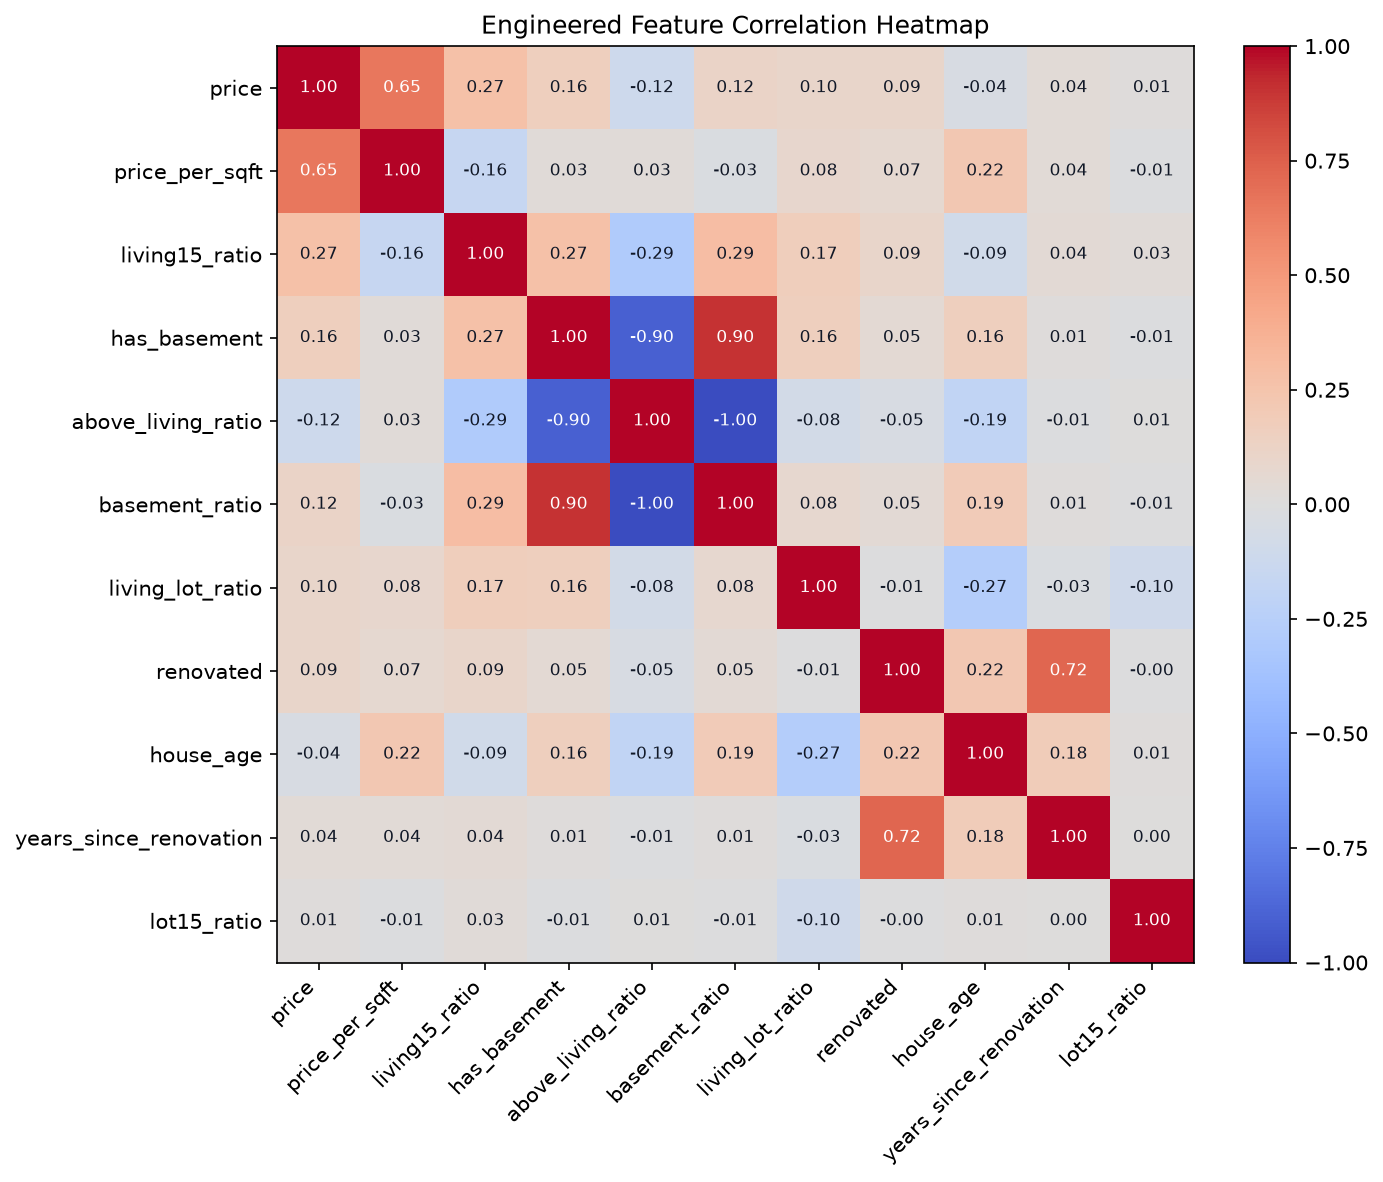

In [5]:
import importlib
from IPython.display import Markdown, display
import processing_own_phase.phase_5_feature_engineering as phase_5

phase_5 = importlib.reload(phase_5)
train_feature_df, val_feature_df, test_feature_df, feature_summary, feature_plot_paths = phase_5.run_phase_5_feature_engineering(
    train_clean_df,
    val_clean_df,
    test_clean_df,
    config,
)

display(Markdown("### Feature engineering shape check"))
display(phase_5.style_colored_table(feature_summary["shape_table"], "Shape before and after Phase 5"))

display(Markdown("### New features"))
display(phase_5.style_colored_table(feature_summary["feature_steps"], "Created features and model-input decision"))

display(Markdown("### Feature quality check"))
display(phase_5.style_colored_table(feature_summary["feature_quality"], "Engineered feature statistics"))

display(Markdown("### Target skewness check"))
display(phase_5.style_colored_table(feature_summary["target_skewness"], "Price skewness before Phase 6 target transform"))

display(Markdown("### Leakage guard"))
display(phase_5.style_colored_table(feature_summary["leakage_guard"], "Features not allowed as model input"))

display(Markdown("### Deferred items"))
display(phase_5.style_colored_table(feature_summary["deferred_steps"], "Items handled in later phases"))

display(Markdown("### Feature preview"))
display(phase_5.style_colored_table(train_feature_df.head(), "Training data after feature engineering"))

phase_5.display_path_collection(feature_plot_paths)


## Phase 6 - Split Data into X and y


In [6]:
import importlib
import processing_own_phase.phase_6_split_data_xy as phase_6

phase_6 = importlib.reload(phase_6)
X_train, y_train, X_val, y_val, X_test, y_test, inverse_transform = phase_6.run_phase_6_split_data_xy(
    train_feature_df,
    val_feature_df,
    test_feature_df,
    config.target_column,
    config.log_transform_target,
)
phase_6_summary = phase_6.build_phase_6_summary(
    train_feature_df,
    val_feature_df,
    test_feature_df,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    config.target_column,
    config.log_transform_target,
)
phase_6.display_phase_6_summary(phase_6_summary)


### X/y split shape check

,split,source_rows,source_columns,X_rows,X_features,y_rows,target_column,target_transform
0,train,17338,31,17338,29,17338,price,log1p(price)
1,validation,2180,31,2180,29,2180,price,log1p(price)
2,test,2179,31,2179,29,2179,price,log1p(price)


### Leakage check

,split,feature,exists_before_split,exists_in_X,status,reason
0,train,price_per_sqft,True,False,Removed,Created from target price
1,validation,price_per_sqft,True,False,Removed,Created from target price
2,test,price_per_sqft,True,False,Removed,Created from target price


### Target distribution

,split,original_min,original_median,original_max,original_skew,model_y_min,model_y_median,model_y_max,model_y_skew,model_target
0,train,1000.000,450000.000,23850000.000,12.884,6.909,13.017,16.987,-0.217,log1p(price)
1,validation,10000.000,445000.000,7950000.000,5.916,9.210,13.006,15.889,0.002,log1p(price)
2,test,1000.000,449000.000,8611110.000,6.797,6.909,13.015,15.969,-1.555,log1p(price)


### Target transform

,item,value,reason
0,Target split,X drops price; y keeps price,Separate model inputs from label
1,Transform,y = log1p(price),Reduce right skew and make training more stable
2,Inverse transform,price_pred = expm1(y_pred),Return predictions to house-price scale


## Phase 7 - Preprocessing Pipeline bằng scikit-learn


In [7]:
import importlib
import processing_own_phase.phase_7_preprocessing_pipeline as phase_7

phase_7 = importlib.reload(phase_7)
X_train_processed, X_val_processed, X_test_processed, preprocessor, feature_names, numerical_features, categorical_features = phase_7.run_phase_7_preprocessing_pipeline(
    X_train,
    X_val,
    X_test,
    config,
)
phase_7_summary = phase_7.build_phase_7_summary(
    X_train,
    X_val,
    X_test,
    X_train_processed,
    X_val_processed,
    X_test_processed,
    config,
    feature_names,
    numerical_features,
    categorical_features,
)
phase_7.display_phase_7_summary(phase_7_summary)


### Preprocessing steps

,feature_group,step,library,purpose
0,Numerical,SimpleImputer(strategy='median'),sklearn,Fill missing numeric values using train median
1,Numerical,StandardScaler(),sklearn,Scale numeric features for stable MLP training
2,Categorical,SimpleImputer(strategy='most_frequent'),sklearn,Fill missing categorical values using train mode
3,Categorical,OneHotEncoder(handle_unknown='ignore'),sklearn,Encode categories and avoid errors on unseen validation/test categories
4,All,ColumnTransformer + Pipeline,sklearn,Apply separate preprocessing branches without data leakage


### Data leakage rules

,split,method,meaning
0,Training,fit_transform(),"Learn imputer values, scaler statistics, and one-hot categories from train"
1,Validation,transform(),Reuse preprocessing learned from train
2,Testing,transform(),Reuse preprocessing learned from train


### Feature groups

...

,split,raw_rows,raw_features,processed_rows,processed_features,dtype
0,train,17338,29,17338,98,float32
1,validation,2180,29,2180,98,float32
2,test,2179,29,2179,98,float32


### Processed quality check

,split,nan_values,infinite_values,finite_ratio,mean,std
0,train,0,0,1.000,0.010,0.544
1,validation,0,0,1.000,0.010,0.658
2,test,0,0,1.000,0.011,0.546


### Saved artifacts

,artifact,path,exists,feature_names
0,preprocess_pipeline.joblib,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/preprocess_pipeline.joblib,True,98


## Phase 8 - Feature Scaling


In [8]:
import importlib
import processing_own_phase.phase_8_feature_scaling as phase_8

phase_8 = importlib.reload(phase_8)
phase_8_summary = phase_8.build_phase_8_summary(X_train_processed, X_val_processed, X_test_processed)
phase_8.display_phase_8_summary(phase_8_summary)


### Scaling output check

,split,rows,processed_features,mean_of_feature_means,mean_abs_feature_mean,mean_of_feature_stds,min_value,max_value,nan_values,infinite_values
0,train,17338,98,0.010,0.010,0.368,-5.800,58.945,0,0
1,validation,2180,98,0.010,0.016,0.391,-3.707,179.229,0,0
2,test,2179,98,0.011,0.013,0.367,-5.800,37.054,0,0


### Scaling decisions

,item,decision,reason
0,Where StandardScaler is fitted,Phase 7,Scaling is part of the sklearn preprocessing pipeline
1,What Phase 8 does,Audit only,Avoid fitting another scaler and keep train-only fit logic clear
2,Leakage prevention,No fit on validation/test,Validation and test must only use transforms learned from train
3,One-hot columns,Not centered like numeric columns,Processed output contains both scaled numeric columns and one-hot categorical columns


## Phase 9 - Create PyTorch Dataset


In [9]:
import importlib
import processing_own_phase.phase_9_pytorch_dataset as phase_9

phase_9 = importlib.reload(phase_9)
train_dataset, val_dataset, test_dataset = phase_9.run_phase_9_pytorch_dataset(
    X_train_processed,
    y_train,
    X_val_processed,
    y_val,
    X_test_processed,
    y_test,
)
phase_9_summary = phase_9.build_phase_9_summary(train_dataset, val_dataset, test_dataset)
phase_9.display_phase_9_summary(phase_9_summary)


### TensorDataset outputs

,split,samples,X_shape,y_shape,X_dtype,y_dtype,target_is_column_vector
0,train,17338,"(17338, 98)","(17338, 1)",torch.float32,torch.float32,True
1,validation,2180,"(2180, 98)","(2180, 1)",torch.float32,torch.float32,True
2,test,2179,"(2179, 98)","(2179, 1)",torch.float32,torch.float32,True


### Tensor requirements

,component,requirement,reason
0,Features,"torch.float32 with shape (n_samples, n_features)",MLP Linear layers expect numeric floating-point input
1,Target,"torch.float32 with shape (n_samples, 1)",Regression model output layer returns one value per sample
2,Dataset,"TensorDataset(X_tensor, y_tensor)",DataLoader can create batches from paired tensors


## Phase 10 - Create PyTorch DataLoader


In [10]:
import importlib
import processing_own_phase.phase_10_pytorch_dataloader as phase_10

phase_10 = importlib.reload(phase_10)
train_loader, val_loader, test_loader = phase_10.run_phase_10_pytorch_dataloader(
    train_dataset,
    val_dataset,
    test_dataset,
    config,
)
phase_10_summary = phase_10.build_phase_10_summary(train_loader, val_loader, test_loader)
phase_10.display_phase_10_summary(phase_10_summary)


### DataLoader outputs

,split,samples,batch_size,batches,expected_batches,shuffle,first_X_batch_shape,first_y_batch_shape
0,train,17338,64,271,271,True,"(64, 98)","(64, 1)"
1,validation,2180,64,35,35,False,"(64, 98)","(64, 1)"
2,test,2179,64,35,35,False,"(64, 98)","(64, 1)"


### Shuffle rules

,split,shuffle,reason
0,train,True,Random batches reduce order bias during gradient updates
1,validation,False,"Evaluation does not update weights, so fixed order is easier to reproduce"
2,test,False,Final evaluation should be deterministic


## Phase 11 - Build MLP Regression Model with PyTorch


In [11]:
import importlib
import processing_own_phase.phase_11_build_mlp_model as phase_11

phase_11 = importlib.reload(phase_11)
model, phase_11_summary = phase_11.run_phase_11_build_mlp_model(
    X_train_processed.shape[1],
    config.hidden_units,
    config.dropout,
)
phase_11.display_phase_11_summary(phase_11_summary)


### MLP architecture

,layer,units,activation,purpose
0,Input,98,-,Receive processed features
1,Hidden 1,64,ReLU,Learn nonlinear feature interactions
2,Output,1,Linear,Predict one regression value


### Model summary

,model,input_dim,hidden_layers,hidden_units,dropout,output_dim,trainable_parameters
0,MLPRegression,98,1,"(64,)",0.000,1,6401


## Phase 12 - Model Configuration


In [12]:
import importlib
import processing_own_phase.phase_12_model_configuration as phase_12

phase_12 = importlib.reload(phase_12)
hyperparameters, phase_12_summary = phase_12.run_phase_12_model_configuration(config)
phase_12.display_phase_12_summary(phase_12_summary)


### Hyperparameters

,hyperparameter,value,meaning
0,learning_rate,0.0005,Step size for Adam weight updates
1,batch_size,64,Number of samples per training batch
2,epochs,150,Maximum number of passes over the training set
3,hidden_units,"(64,)",MLP hidden layer sizes
4,dropout,0.0,Dropout rate to reduce overfitting
5,weight_decay,0.0,L2 regularization strength
6,patience,15,Early stopping wait epochs
7,min_delta,0.0001,Minimum validation-loss improvement for early stopping
8,loss_function,mse,"Regression objective: mse, huber or smooth_l1"
9,huber_delta,1.0,Huber/SmoothL1 transition point for robust regression


### Training components

,component,value,purpose
0,device,cpu,"Run training on GPU if available, otherwise CPU"
1,loss_fn,torch.nn.MSELoss() / HuberLoss() / SmoothL1Loss(),Optimize regression error; robust losses reduce sensitivity to high-error outliers
2,optimizer,torch.optim.Adam(),Update weights using adaptive learning rates
3,tracked_metrics,"MAE, MSE, RMSE, R2",Monitor training and validation behavior


## Phase 13 - Train MLP with PyTorch


In [13]:
import importlib
import processing_own_phase.phase_13_train_mlp_pytorch as phase_13

phase_13 = importlib.reload(phase_13)
training_log, early_stopping = phase_13.run_phase_13_train_mlp_pytorch(
    model,
    train_loader,
    val_loader,
    hyperparameters,
    config,
)
phase_13_summary = phase_13.build_phase_13_summary(training_log, config.log_transform_target)
phase_13.display_phase_13_summary(phase_13_summary)


### Training loop steps

,step,purpose
0,model.train(),Enable training behavior such as dropout
1,forward pass,Predict y for each batch
2,"loss = configured_loss(output, y)",Measure regression error with MSE or a robust loss
3,optimizer.zero_grad(),Clear old gradients
4,loss.backward(),Compute gradients
5,optional gradient clipping,Limit gradient norm when configured for robust-loss trials
6,optimizer.step(),Update model weights
7,model.eval() + torch.no_grad(),Validate without updating weights
8,append training log,Store loss and metrics for later monitoring


### Training result

,epochs_ran,best_epoch,best_validation_loss,final_train_loss,final_validation_loss,final_validation_rmse,stopped_early
0,49,34,0.068,0.060,0.087,0.300,True


### Metric scale

,metric_location,scale,note
0,Phase 13 training log,log1p(price),Phase 18 should inverse-transform predictions with expm1 for real-price metrics


### Training log tail

,epoch,train_loss,validation_loss,train_mae,train_mse,train_rmse,train_r2,validation_mae,validation_mse,validation_rmse,validation_r2,learning_rate,loss_function,huber_delta,gradient_clip_norm,gradient_norm,epoch_time_seconds,device,stopped_early
44,45,0.060,0.076,0.140,0.060,0.245,0.807,0.159,0.078,0.279,0.734,0.001,mse,1.000,5.000,0.909,0.117,cpu,False
45,46,0.060,0.091,0.141,0.060,0.245,0.807,0.154,0.093,0.305,0.683,0.001,mse,1.000,5.000,0.929,0.107,cpu,False
46,47,0.061,0.129,0.141,0.061,0.247,0.804,0.156,0.132,0.364,0.549,0.001,mse,1.000,5.000,0.985,0.102,cpu,False
47,48,0.060,0.114,0.139,0.060,0.245,0.808,0.160,0.117,0.342,0.602,0.001,mse,1.000,5.000,0.923,0.096,cpu,False
48,49,0.060,0.087,0.142,0.060,0.245,0.808,0.157,0.090,0.300,0.694,0.001,mse,1.000,5.000,0.935,0.098,cpu,True


## Phase 14 - Training Log and Monitoring


In [14]:
import importlib
import processing_own_phase.phase_14_training_log_monitoring as phase_14

phase_14 = importlib.reload(phase_14)
training_log_path, curve_data, phase_14_summary = phase_14.run_phase_14_training_log_monitoring(training_log, config)
phase_14.display_phase_14_summary(phase_14_summary)
display_path_collection({"training_log": training_log_path})


### Training log summary

,epochs_ran,best_epoch,best_validation_loss,best_validation_rmse,best_validation_r2,final_train_loss,final_validation_loss,total_training_time_seconds,stopped_early,saved_log_path
0,49,34,0.068,0.264,0.762,0.060,0.087,5.243,True,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/logs/training_log.csv


### Column check

,column,type,available,purpose
0,epoch,required,True,Needed for core training monitoring
1,train_loss,required,True,Needed for core training monitoring
2,validation_loss,required,True,Needed for core training monitoring
3,train_mae,required,True,Needed for core training monitoring
4,validation_mae,required,True,Needed for core training monitoring
5,validation_rmse,required,True,Needed for core training monitoring
6,validation_r2,required,True,Needed for core training monitoring
7,train_rmse,optional,True,Useful for deeper diagnosis if available
8,train_r2,optional,True,Useful for deeper diagnosis if available
9,learning_rate,optional,True,Useful for deeper diagnosis if available


### Last epochs

,epoch,train_loss,validation_loss,train_mae,validation_mae,validation_rmse,validation_r2,learning_rate,gradient_norm,epoch_time_seconds,stopped_early
44,45,0.060,0.076,0.140,0.159,0.279,0.734,0.001,0.909,0.117,False
45,46,0.060,0.091,0.141,0.154,0.305,0.683,0.001,0.929,0.107,False
46,47,0.061,0.129,0.141,0.156,0.364,0.549,0.001,0.985,0.102,False
47,48,0.060,0.114,0.139,0.160,0.342,0.602,0.001,0.923,0.096,False
48,49,0.060,0.087,0.142,0.157,0.300,0.694,0.001,0.935,0.098,True


training_log /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/logs/training_log.csv


## Phase 15 - Visualize Training Process


### Created training plots

,plot_name,saved_path,status
0,training_loss_curve,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/training_loss_curve.png,created
1,mae_curve,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/mae_curve.png,created
2,validation_rmse_curve,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/validation_rmse_curve.png,created
3,validation_r2_curve,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/validation_r2_curve.png,created
4,learning_rate_curve,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/learning_rate_curve.png,created
5,gradient_norm_curve,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/gradient_norm_curve.png,created


### Skipped optional plots

,plot,reason
0,optional_residual_distribution,Residual analysis needs y_true and y_pred; main handling is Phase 18/19


training_loss_curve /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/training_loss_curve.png


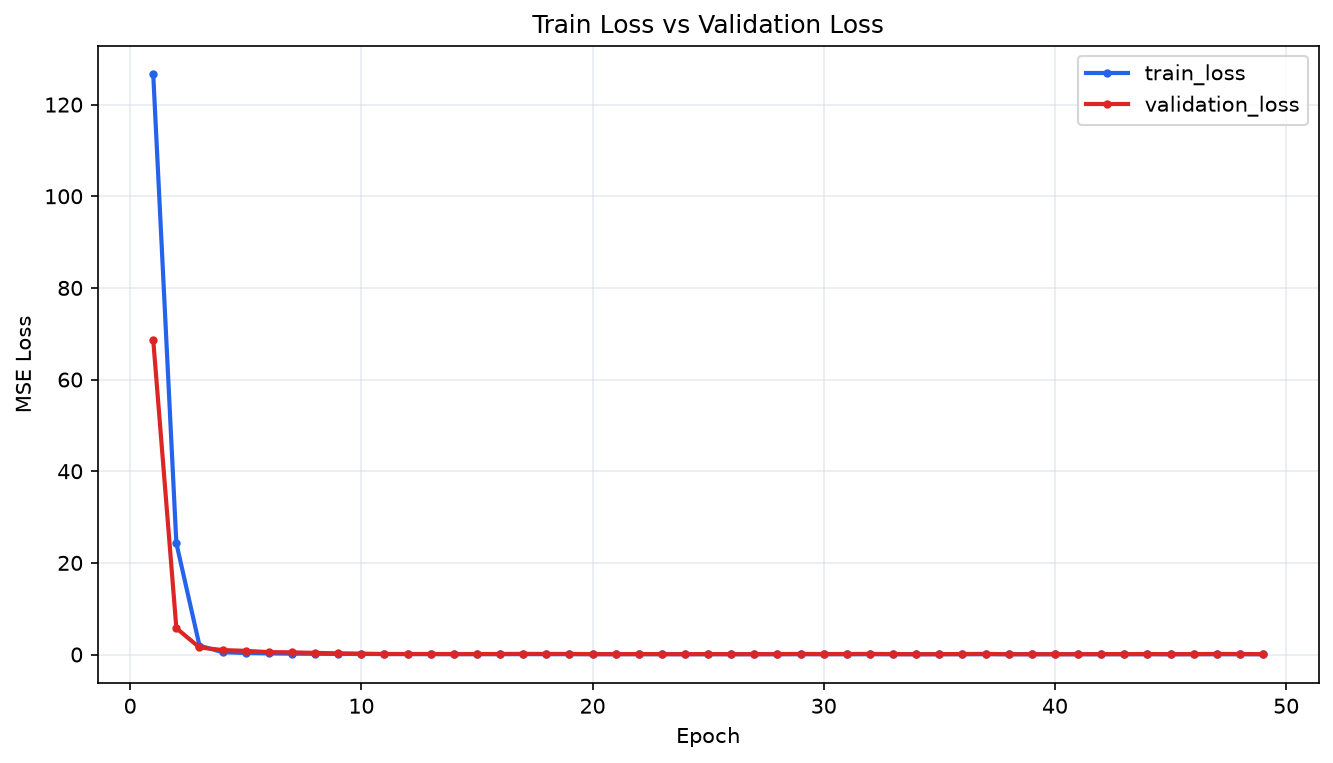

mae_curve /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/mae_curve.png


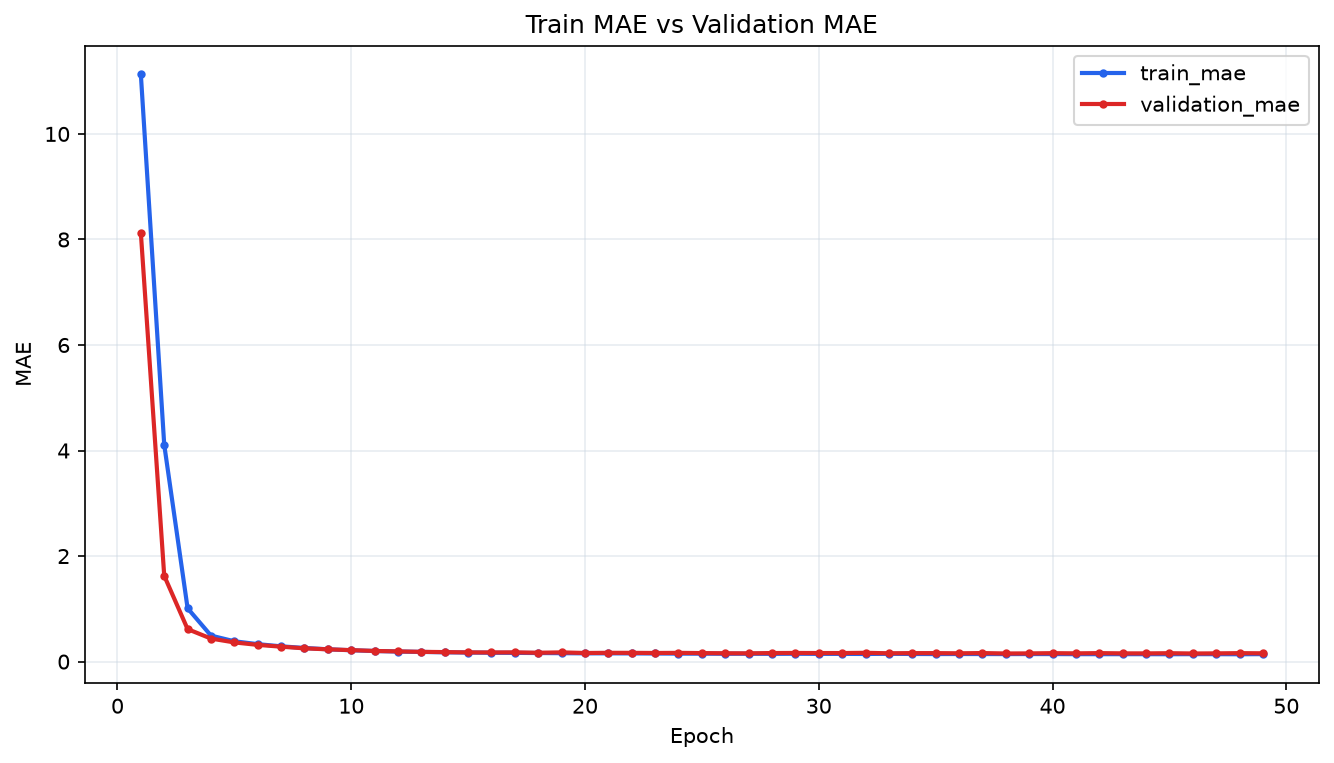

validation_rmse_curve /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/validation_rmse_curve.png


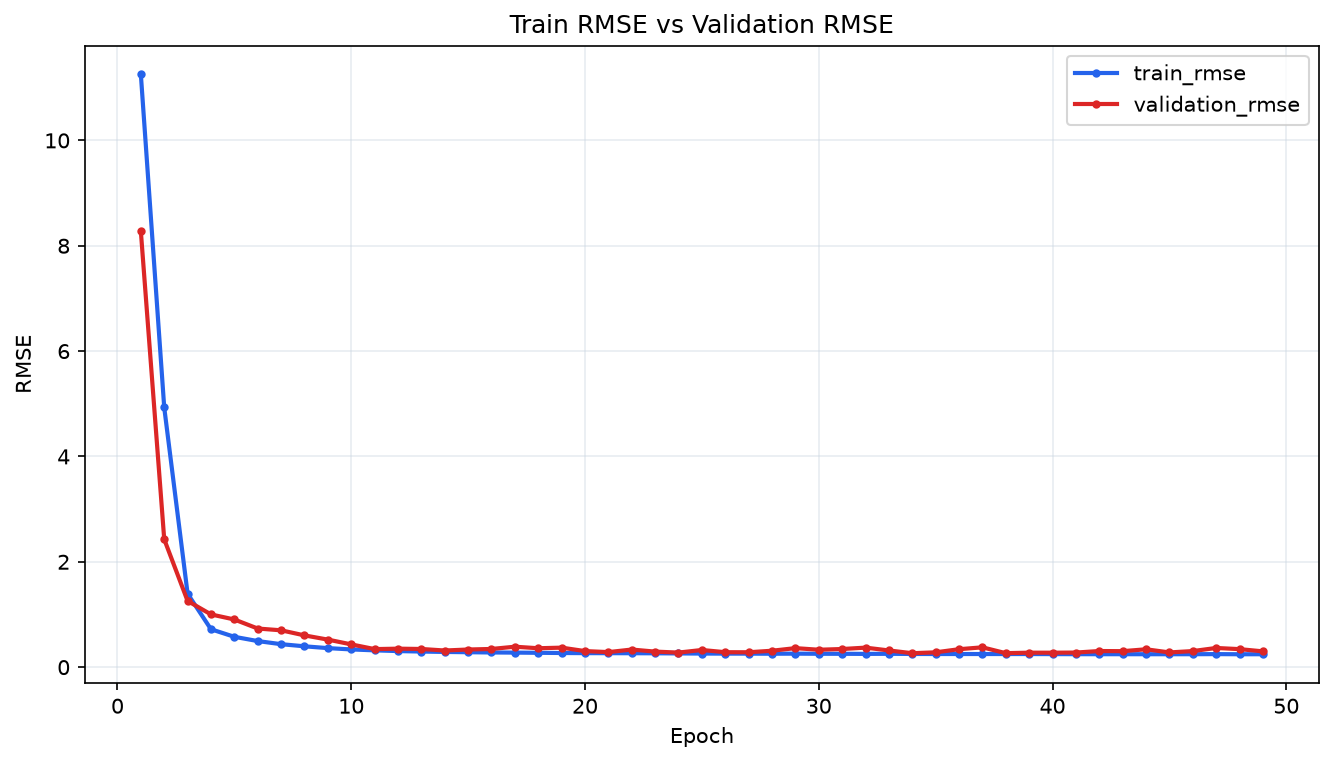

validation_r2_curve /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/validation_r2_curve.png


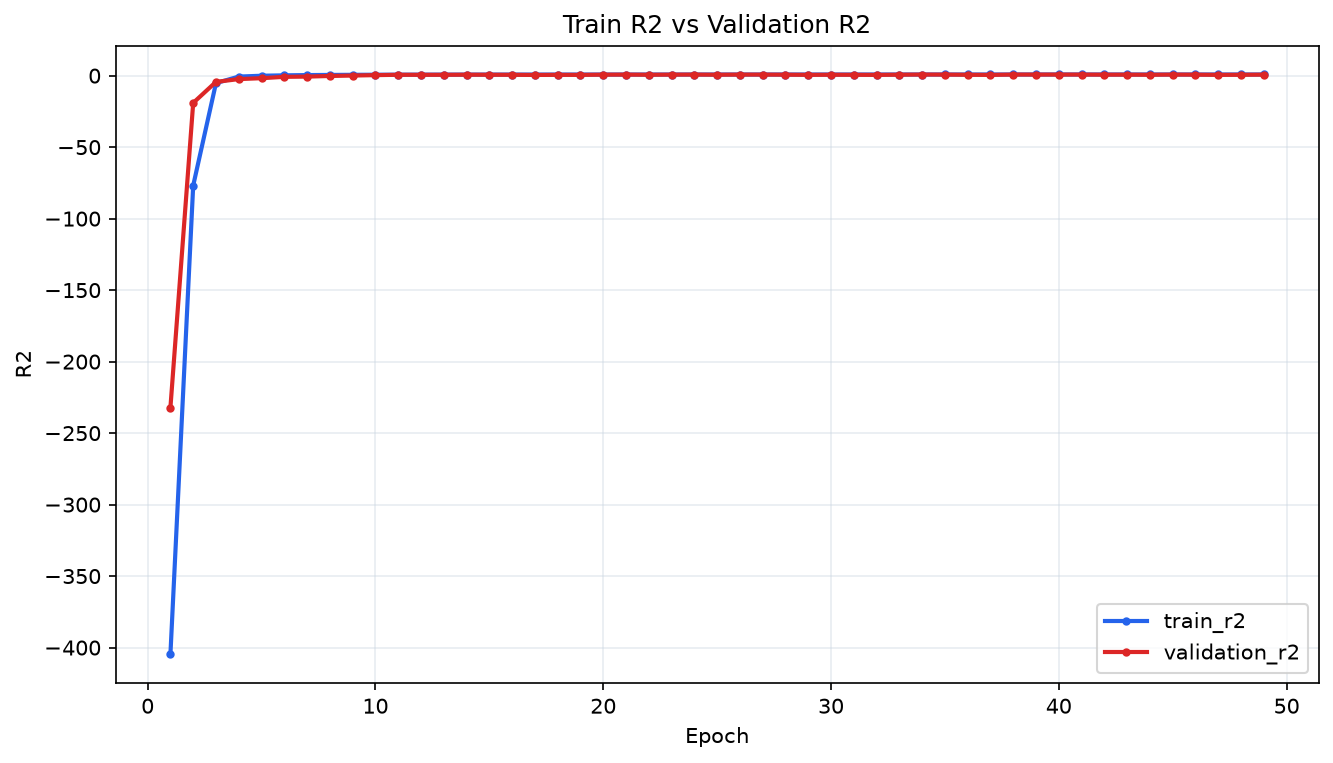

learning_rate_curve /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/learning_rate_curve.png


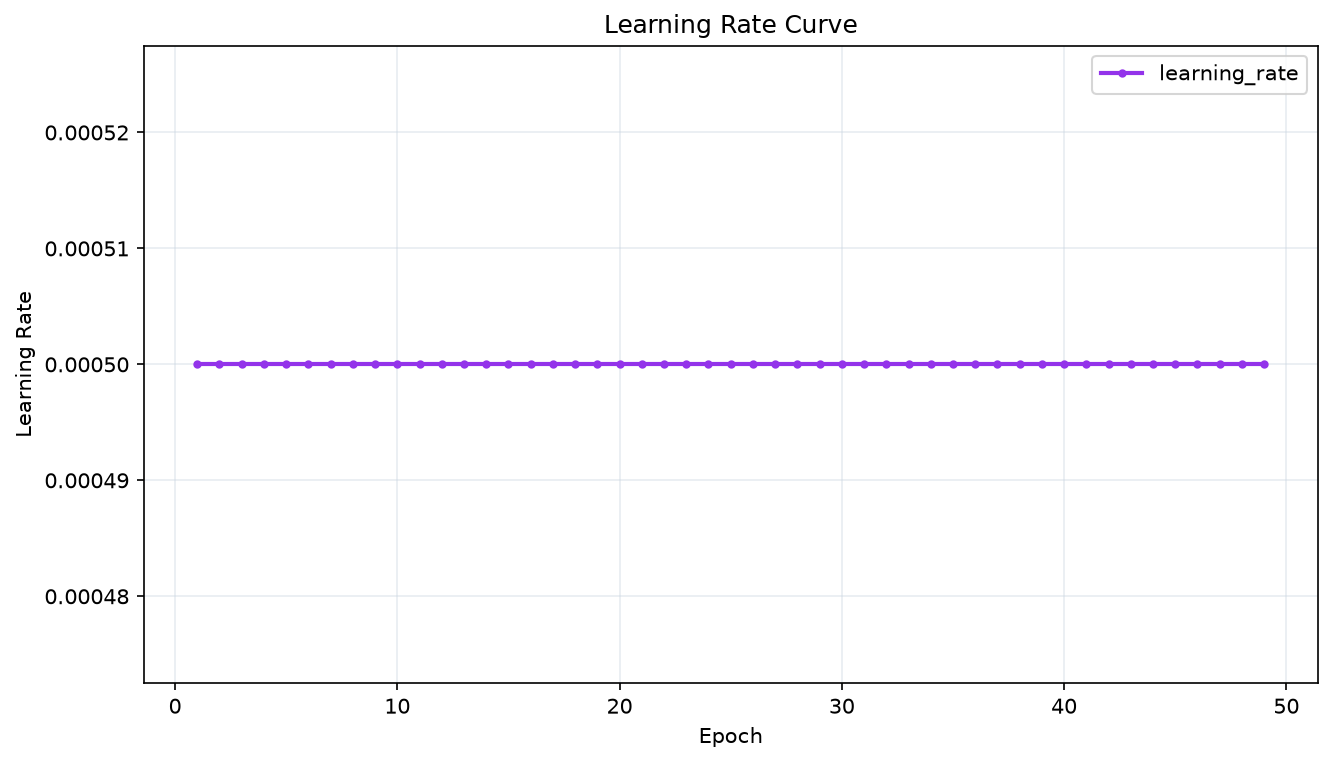

gradient_norm_curve /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/gradient_norm_curve.png


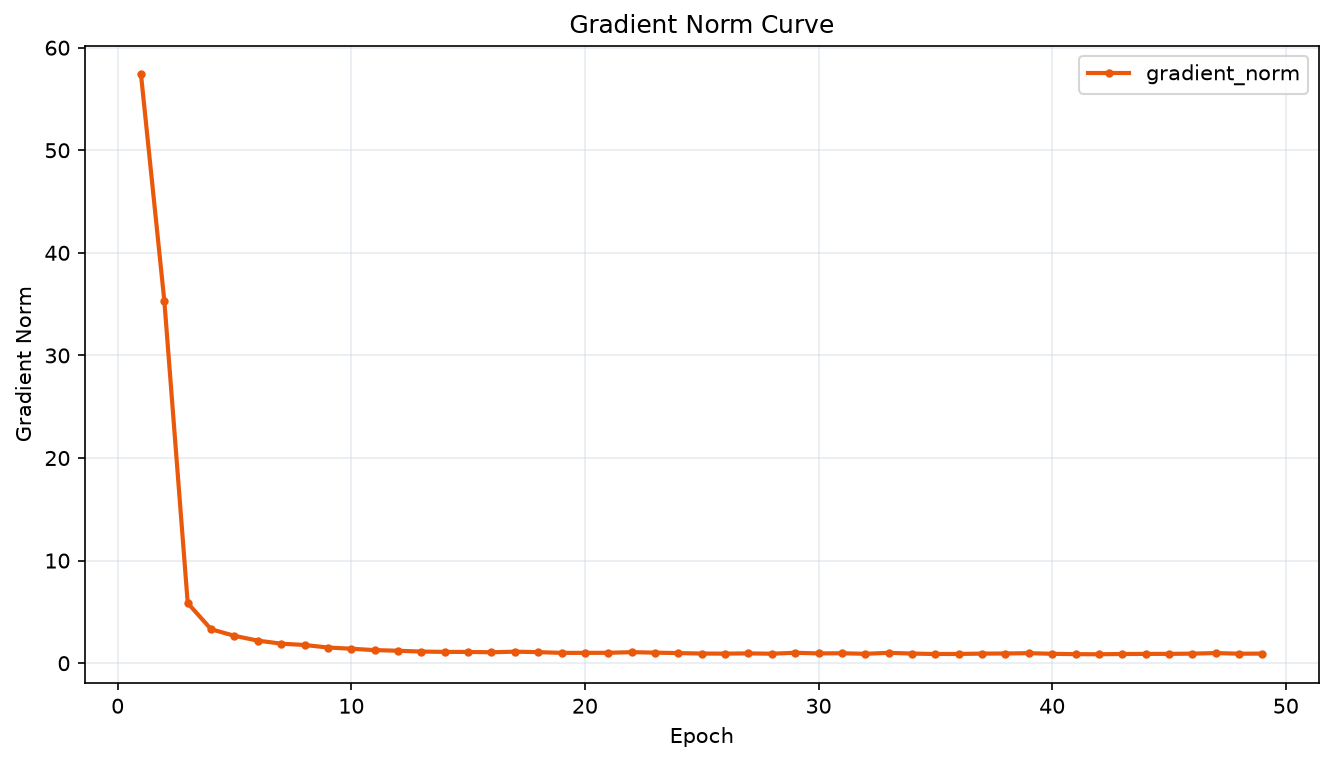

In [15]:
import importlib
import processing_own_phase.phase_15_visualize_training as phase_15

phase_15 = importlib.reload(phase_15)
training_plot_paths, phase_15_summary = phase_15.run_phase_15_visualize_training(training_log, config)
phase_15.display_phase_15_summary(phase_15_summary)
display_path_collection(training_plot_paths)


## Phase 16 - Early Stopping and Best Model Saving


In [16]:
import importlib
import processing_own_phase.phase_16_early_stopping as phase_16

phase_16 = importlib.reload(phase_16)
early_stopping_summary, phase_16_summary = phase_16.run_phase_16_early_stopping(early_stopping, config)
phase_16.display_phase_16_summary(phase_16_summary)
display_path_collection({"early_stopping_summary": early_stopping_summary["summary_path"]})


### Early stopping summary

,item,value
0,best_loss,0.068
1,best_epoch,34
2,patience,15
3,min_delta,0.000
4,counter,15
5,model_path,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/best_mlp_model.pth
6,best_model_saved,True
7,restore_best_model,True
8,status,best model saved
9,summary_path,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/logs/early_stopping_summary.json


### Early stopping rules

,condition,action
0,validation_loss improves by at least min_delta,save best_mlp_model.pth and reset counter
1,validation_loss does not improve,increase patience counter
2,counter reaches patience,stop training and restore best model
3,best model exists,Phase 18 should evaluate this restored/best model


early_stopping_summary /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/logs/early_stopping_summary.json


## Phase 17 - Hyperparameter Exploration

Phase này chạy thật một grid nhỏ có kiểm soát để so sánh learning rate, hidden layers, dropout, weight decay và robust loss. Kết quả được đánh giá trên validation set ở thang giá gốc sau inverse transform, nên có thể đọc trực tiếp bằng đơn vị price.


### Hyperparameter exploration overview

,total_trials_in_table,ran_experiments,results_path,note
0,8,True,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/hyperparameter_results.csv,Completed trials are ranked by validation_original_rmse when available


### Hyperparameter table

,trial,learning_rate,hidden_units,batch_size,dropout,weight_decay,loss_function,huber_delta,gradient_clip_norm,best_epoch,validation_loss,validation_rmse,validation_original_mae,validation_original_mse,validation_original_rmse,validation_original_r2,training_time_seconds,validation_inference_time_seconds,target_scale,device,best_model_path,status
0,1,0.001,"(128, 64)",128,0.100,0.000,mse,1.000,5.000,45,0.071,0.271,91564.262,55798158816.195,236216.339,0.629,4.388,0.005,original price scale after inverse transform,cpu,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/hyperparameter_search/trial_01_best.pth,completed
1,2,0.001,"(128, 64)",128,0.100,0.000,huber,1.000,5.000,44,0.033,0.328,1182631.454,2587281600353707.500,50865328.077,-17219.594,4.368,0.004,original price scale after inverse transform,cpu,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/hyperparameter_search/trial_02_best.pth,completed
2,3,0.001,"(256, 128, 64)",128,0.150,0.000,huber,0.750,5.000,28,0.038,0.431,502383121.055,549968507961071239168.000,23451407376.980,-3660515527.058,4.757,0.006,original price scale after inverse transform,cpu,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/hyperparameter_search/trial_03_best.pth,completed
3,4,0.000,"(256, 128, 64)",64,0.200,0.000,huber,0.500,5.000,30,0.034,0.433,747337488.947,1217216084410181615616.000,34888623997.088,-8101624571.112,8.503,0.006,original price scale after inverse transform,cpu,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/hyperparameter_search/trial_04_best.pth,completed
4,5,0.000,"(128, 128)",64,0.100,0.000,smooth_l1,0.750,5.000,45,0.039,0.371,51030718.320,5657480612388984832.000,2378545902.939,-37655419.868,6.849,0.005,original price scale after inverse transform,cpu,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/hyperparameter_search/trial_05_best.pth,completed
5,6,0.000,"(256, 128)",128,0.200,0.000,smooth_l1,0.500,5.000,42,0.108,1.283,2420741435290456231006699520.000,12774776230439973950205089303981292487121745723622225346560.000,113025555651985069048294539264.000,-85027171705435689289645573933397183039956582400.000,5.397,0.004,original price scale after inverse transform,cpu,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/hyperparameter_search/trial_06_best.pth,completed
6,7,0.001,"(64,)",64,0.000,0.000,mse,1.000,5.000,26,0.082,0.290,144193.822,7315651908652.673,2704746.182,-47.692,3.250,0.004,original price scale after inverse transform,cpu,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/hyperparameter_search/trial_07_best.pth,completed
7,8,0.000,"(512, 256, 128)",128,0.200,0.000,huber,0.750,5.000,29,0.042,0.564,1208476365678.004,3183704413378141229791838208.000,56424324660363.828,-21190303214127880.000,9.720,0.007,original price scale after inverse transform,cpu,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/hyperparameter_search/trial_08_best.pth,completed


### Ranked completed trials

...

### Created hyperparameter plots

,plot_name,saved_path,status
0,validation_rmse_by_trial,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/phase_17_hyperparameter_validation_rmse.png,created


### Parameter meaning

,hyperparameter,meaning
0,learning_rate,Adam step size; too high may oscillate
1,hidden_units,Number of neurons/layers in the MLP
2,batch_size,Samples per weight update
3,dropout,Regularization to reduce overfitting
4,weight_decay,L2 regularization strength
5,loss_function,"mse, huber, or smooth_l1 objective"
6,huber_delta,Transition point for robust losses on log target scale
7,gradient_clip_norm,Optional max gradient norm used to stabilize trials


hyperparameter_results /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/hyperparameter_results.csv
validation_rmse_by_trial /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/training/phase_17_hyperparameter_validation_rmse.png


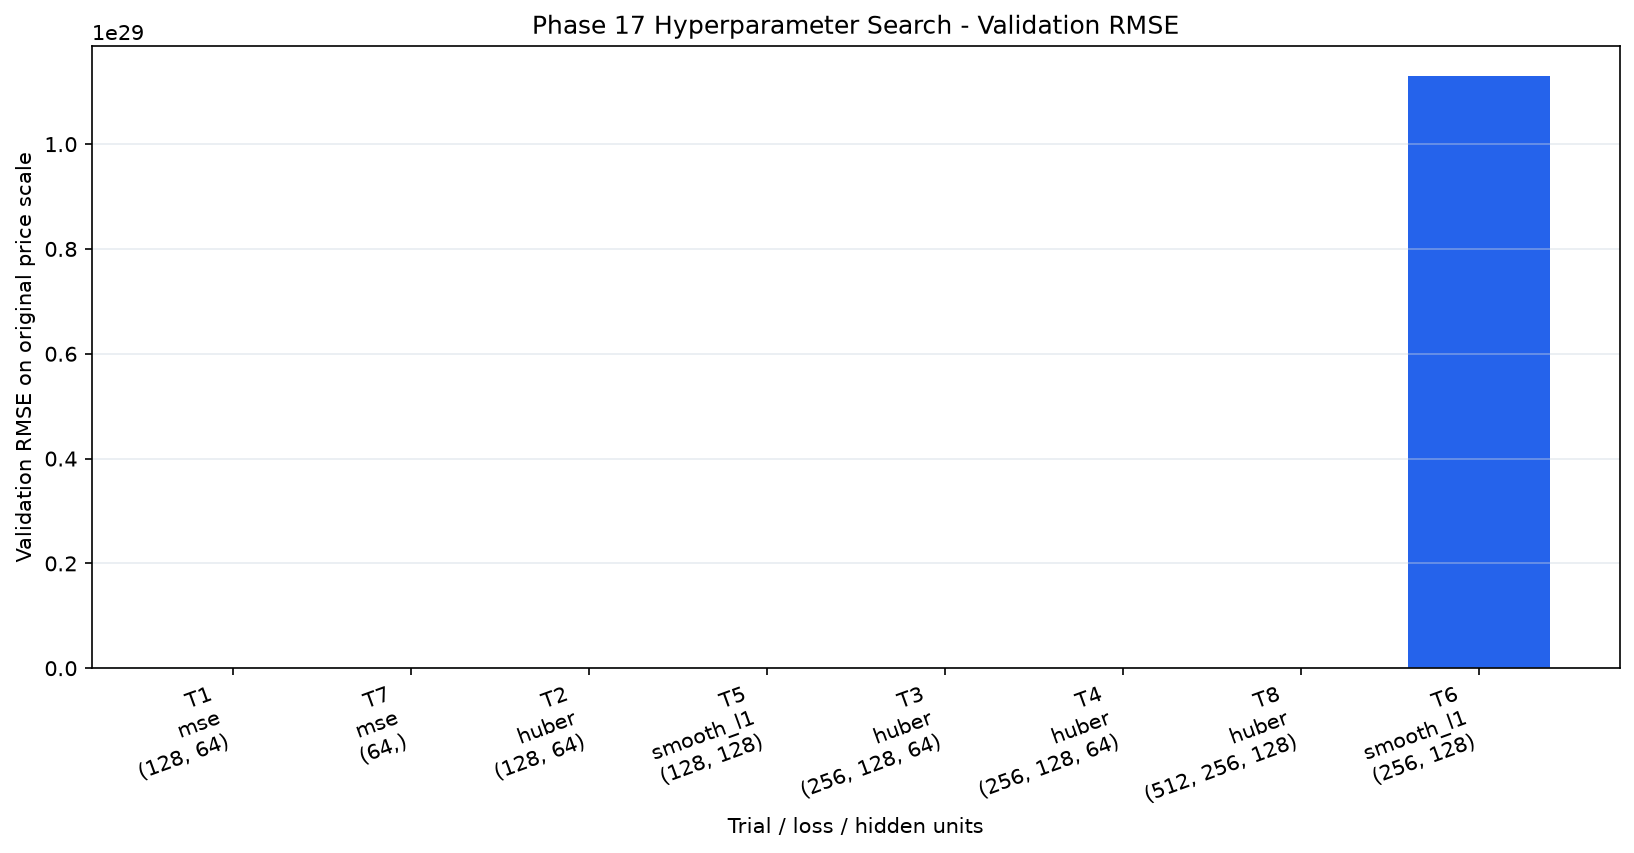

In [17]:
import importlib
import processing_own_phase.phase_17_hyperparameter_exploration as phase_17

phase_17 = importlib.reload(phase_17)
hyperparameter_table, phase_17_summary = phase_17.run_phase_17_hyperparameter_exploration(
    X_train_processed,
    y_train,
    X_val_processed,
    y_val,
    input_dim=X_train_processed.shape[1],
    config=config,
    max_epochs_per_trial=45,
    max_trials=8,
    inverse_transform=inverse_transform,
    patience_per_trial=8,
)
phase_17.display_phase_17_summary(phase_17_summary)
display_path_collection({"hyperparameter_results": config.hyperparameter_results_path})
display_path_collection(
    {
        row["plot_name"]: row["saved_path"]
        for _, row in phase_17_summary["created_plots"].iterrows()
        if row["status"] == "created"
    }
)


## Phase 18 - Evaluate MLP Model on Test Set


In [18]:
import importlib
import processing_own_phase.phase_18_evaluate_mlp as phase_18

phase_18 = importlib.reload(phase_18)
mlp_metrics_df, predictions_df, phase_18_summary = phase_18.run_phase_18_evaluate_mlp(
    model,
    test_loader,
    config,
    inverse_transform,
)
mlp_metrics_df["training_time_seconds"] = float(training_log["epoch_time_seconds"].sum())
mlp_metrics_df.to_csv(config.mlp_metrics_path, index=False)
phase_18_summary["mlp_metrics"] = mlp_metrics_df
phase_18.display_phase_18_summary(phase_18_summary)
display_path_collection({"mlp_metrics": config.mlp_metrics_path, "mlp_predictions": config.predictions_path})


### MLP test metrics

,model,MAE,MSE,RMSE,R2,training_time_seconds,inference_time_seconds,target_scale,device
0,MLP Regression PyTorch,99151.514,93745115448.490,306178.241,0.567,5.243,0.006,original price scale after expm1 inverse transform,cpu


### Metric explanation

,metric,meaning,target_scale
0,MAE,Average absolute prediction error,original price scale after expm1 inverse transform
1,MSE,Average squared prediction error,original price scale after expm1 inverse transform
2,RMSE,"Square root of MSE, easier to read than MSE",original price scale after expm1 inverse transform
3,R2,How much target variation the model explains,original price scale after expm1 inverse transform


### Prediction error summary

,rows,mean_actual_price,mean_predicted_price,mean_residual,median_absolute_error,max_absolute_error,negative_predictions
0,2179,550974.034,523051.072,27922.962,48019.871,7858404.489,0


### Prediction preview

,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error
0,625000.029,453210.693,171789.336,171789.336,27.486
1,382499.969,399887.882,-17387.914,17387.914,4.546
2,424999.871,236487.609,188512.262,188512.262,44.356
3,325000.031,304023.807,20976.224,20976.224,6.454
4,242999.974,217016.250,25983.724,25983.724,10.693
5,429999.804,463428.527,-33428.722,33428.722,7.774
6,612125.157,551945.646,60179.511,60179.511,9.831
7,678499.785,534790.599,143709.186,143709.186,21.180
8,340000.012,323749.027,16250.985,16250.985,4.780
9,269500.106,236777.371,32722.736,32722.736,12.142


mlp_metrics /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/mlp_metrics.csv
mlp_predictions /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/mlp_predictions.csv


## Phase 19 - Predictions and Visualization

Phase này không chỉ vẽ residual và actual-vs-predicted tổng thể, mà còn tách riêng nhóm nhà giá cao để kiểm tra lỗi underprediction. Đây là vùng MLP đang mắc lỗi lớn nhất.


### Created prediction plots

,plot_name,saved_path,status
0,actual_vs_predicted,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/actual_vs_predicted_mlp.png,created
1,actual_vs_predicted_high_end,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/actual_vs_predicted_high_end_mlp.png,created
2,residual_plot,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/residual_plot_mlp.png,created
3,residual_histogram,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/residual_histogram_mlp.png,created
4,error_by_price_range,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/error_by_price_range_mlp.png,created
5,top_20_largest_errors,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/top_20_largest_errors_mlp.png,created
6,high_end_house_rmse,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/high_end_house_rmse_mlp.png,created
7,training_validation_loss,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/training_validation_loss_for_predictions.png,created


### Error by price range

,price_range,samples,mean_actual_price,mean_absolute_error,median_absolute_error,mean_absolute_percentage_error
0,"(999.999, 299980.001]",436,233875.085,43435.245,28346.418,429.006
1,"(299980.001, 397500.076]",437,345198.656,43956.493,32608.693,12.744
2,"(397500.076, 519939.892]",434,450532.251,54005.762,40356.554,12.030
3,"(519939.892, 700000.327]",447,603471.246,89304.966,70239.569,14.774
4,"(700000.327, 8611111.114]",425,1135219.828,269521.351,143519.578,19.678


### High-end house analysis

...

### Top 20 largest errors

,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,case
0,8611111.114,752706.625,7858404.489,7858404.489,91.259,#1
1,6329248.438,646560.203,5682688.235,5682688.235,89.785,#2
2,6359998.062,704594.892,5655403.170,5655403.170,88.921,#3
3,3995001.839,312477.610,3682524.229,3682524.229,92.178,#4
4,1100000.295,4202831.835,-3102831.541,3102831.541,282.076,#5
5,3300001.376,5498054.764,-2198053.389,2198053.389,66.608,#6
6,1649999.398,197794.739,1452204.658,1452204.658,88.012,#7
7,2149998.986,906504.080,1243494.906,1243494.906,57.837,#8
8,2699999.592,1513168.862,1186830.731,1186830.731,43.957,#9
9,1534999.773,379177.463,1155822.310,1155822.310,75.298,#10


### Skipped plots

,plot,reason
0,-,No plots skipped


actual_vs_predicted /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/actual_vs_predicted_mlp.png


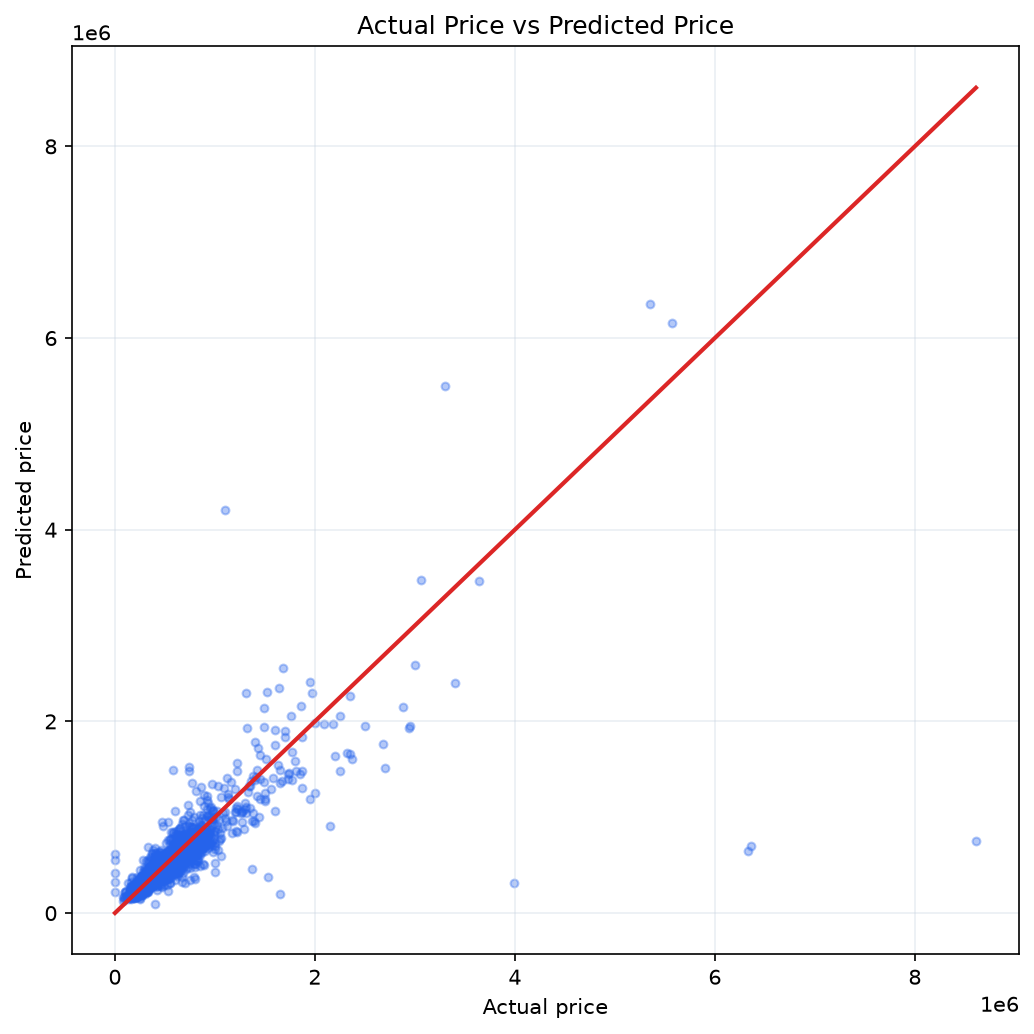

actual_vs_predicted_high_end /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/actual_vs_predicted_high_end_mlp.png


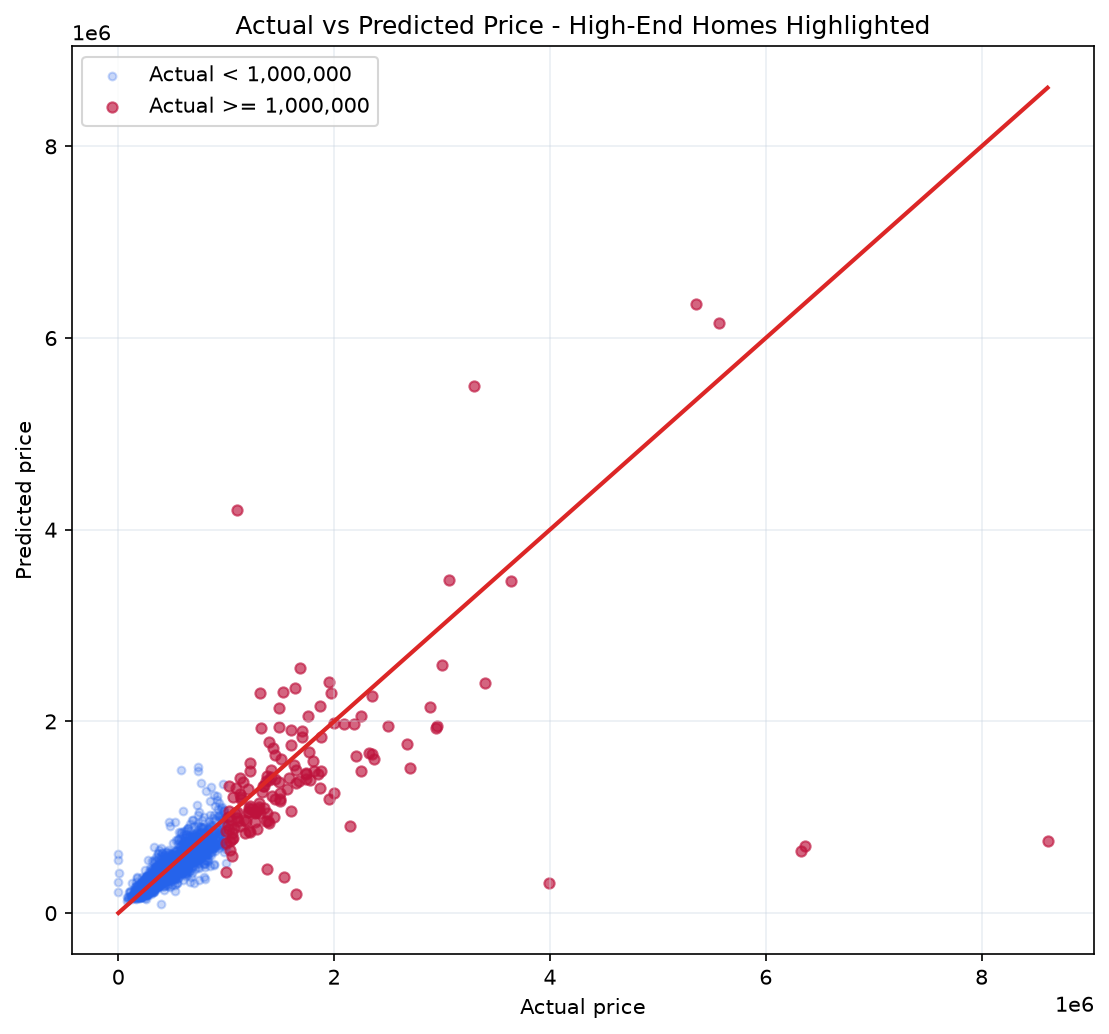

residual_plot /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/residual_plot_mlp.png


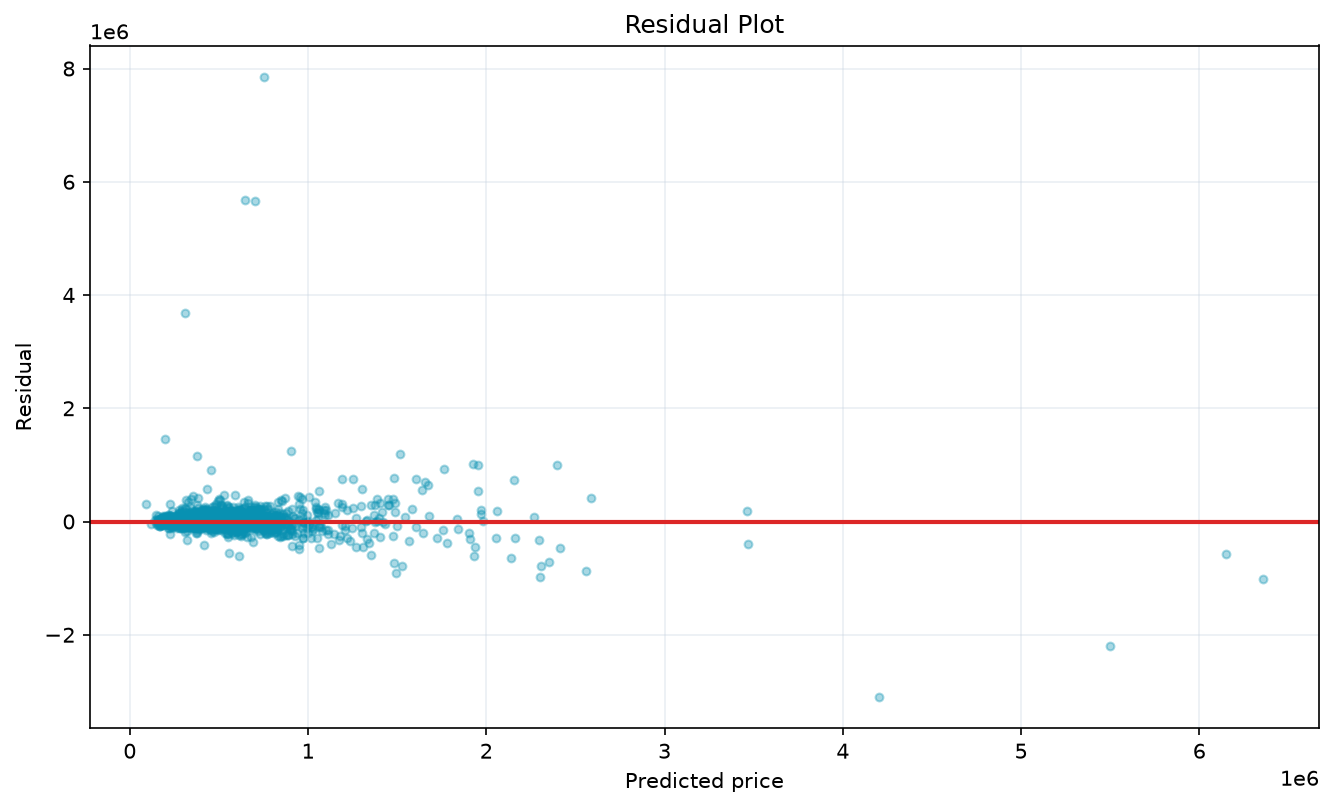

residual_histogram /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/residual_histogram_mlp.png


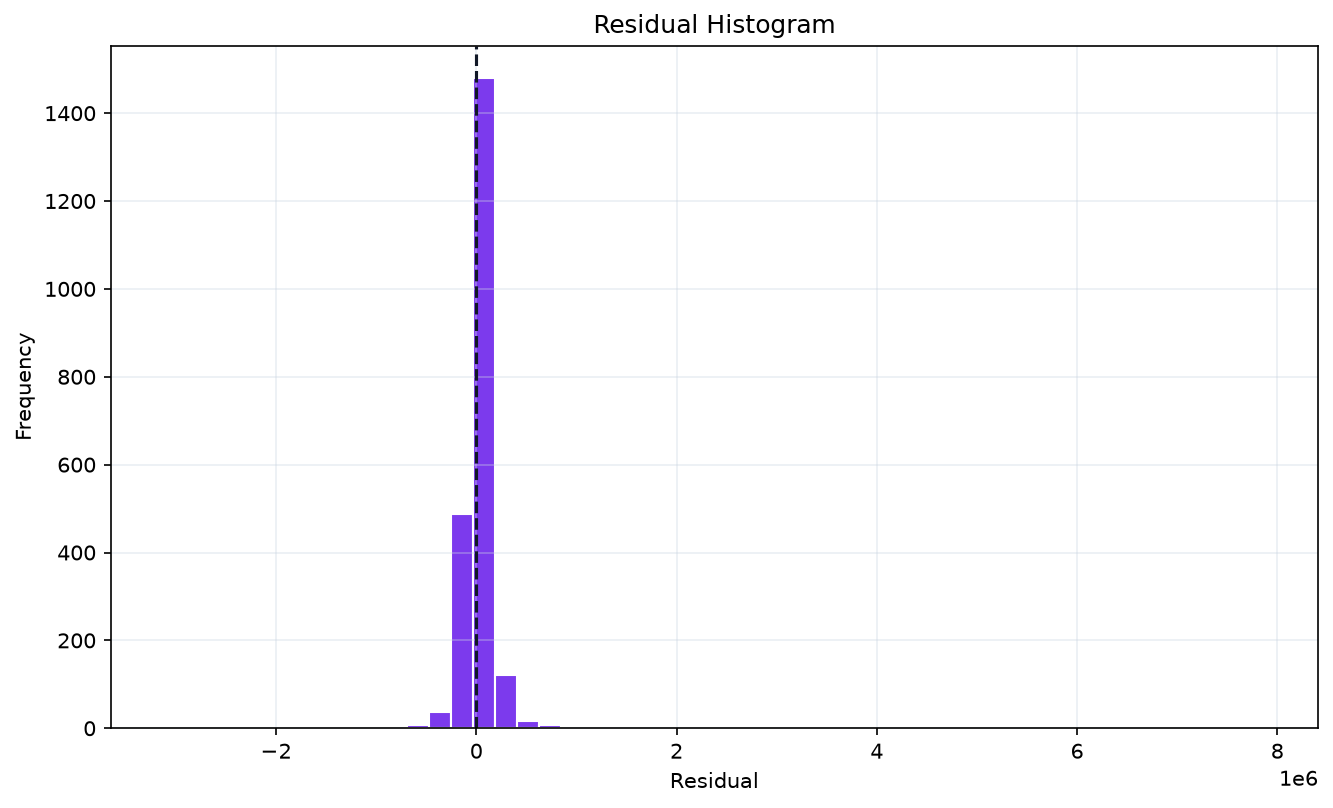

error_by_price_range /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/error_by_price_range_mlp.png


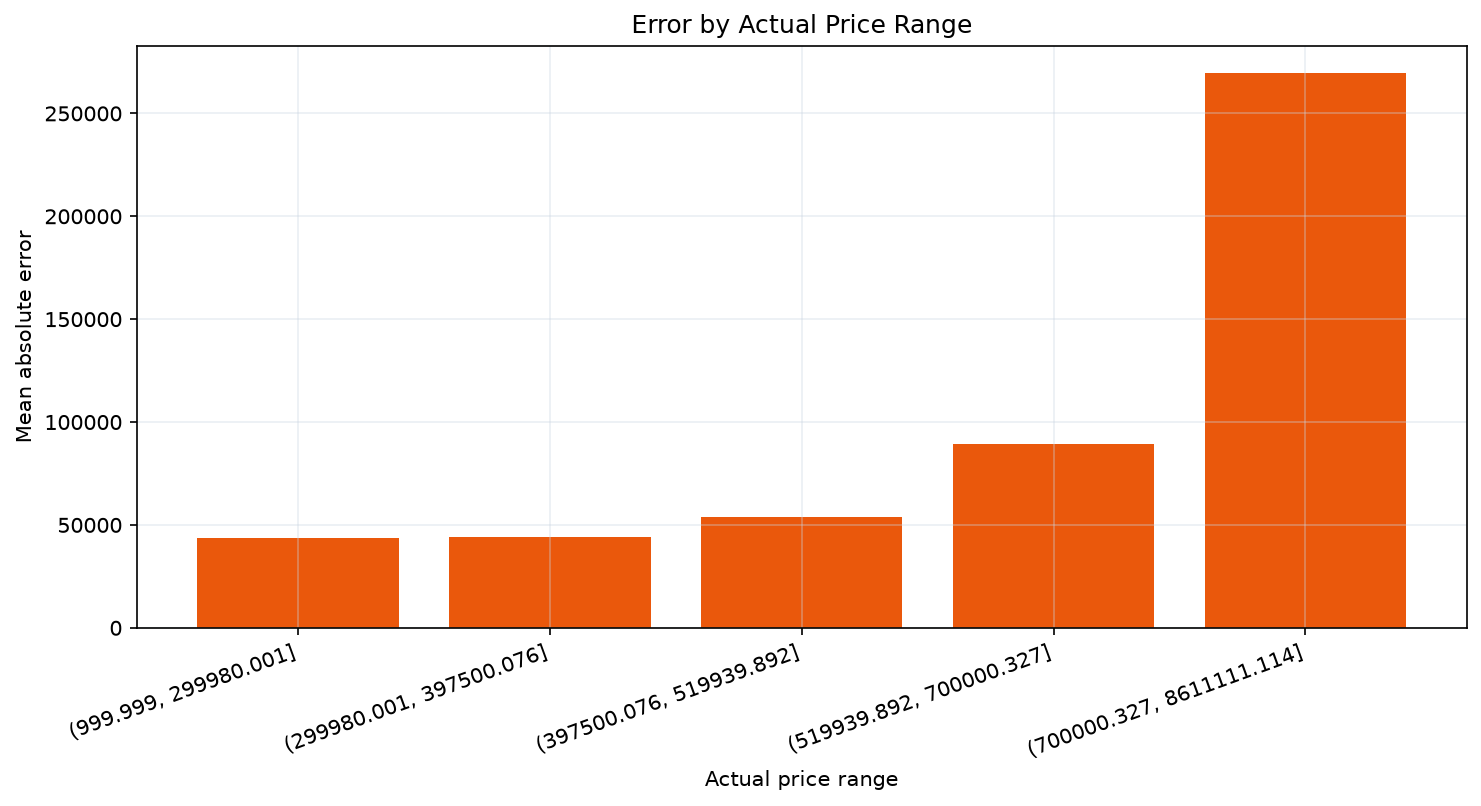

top_20_largest_errors /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/top_20_largest_errors_mlp.png


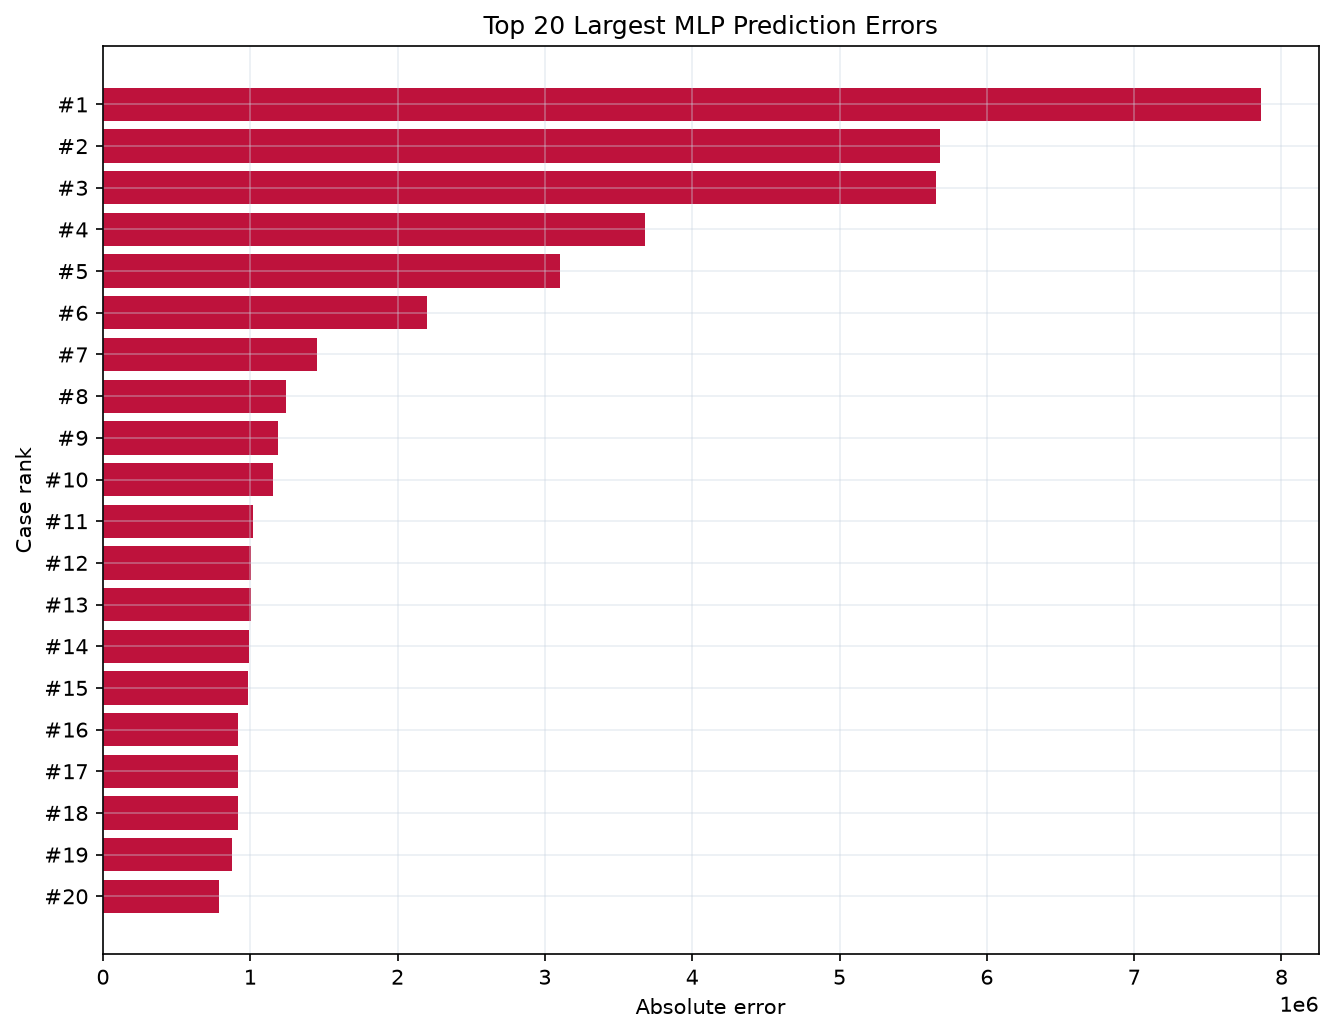

high_end_house_rmse /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/high_end_house_rmse_mlp.png


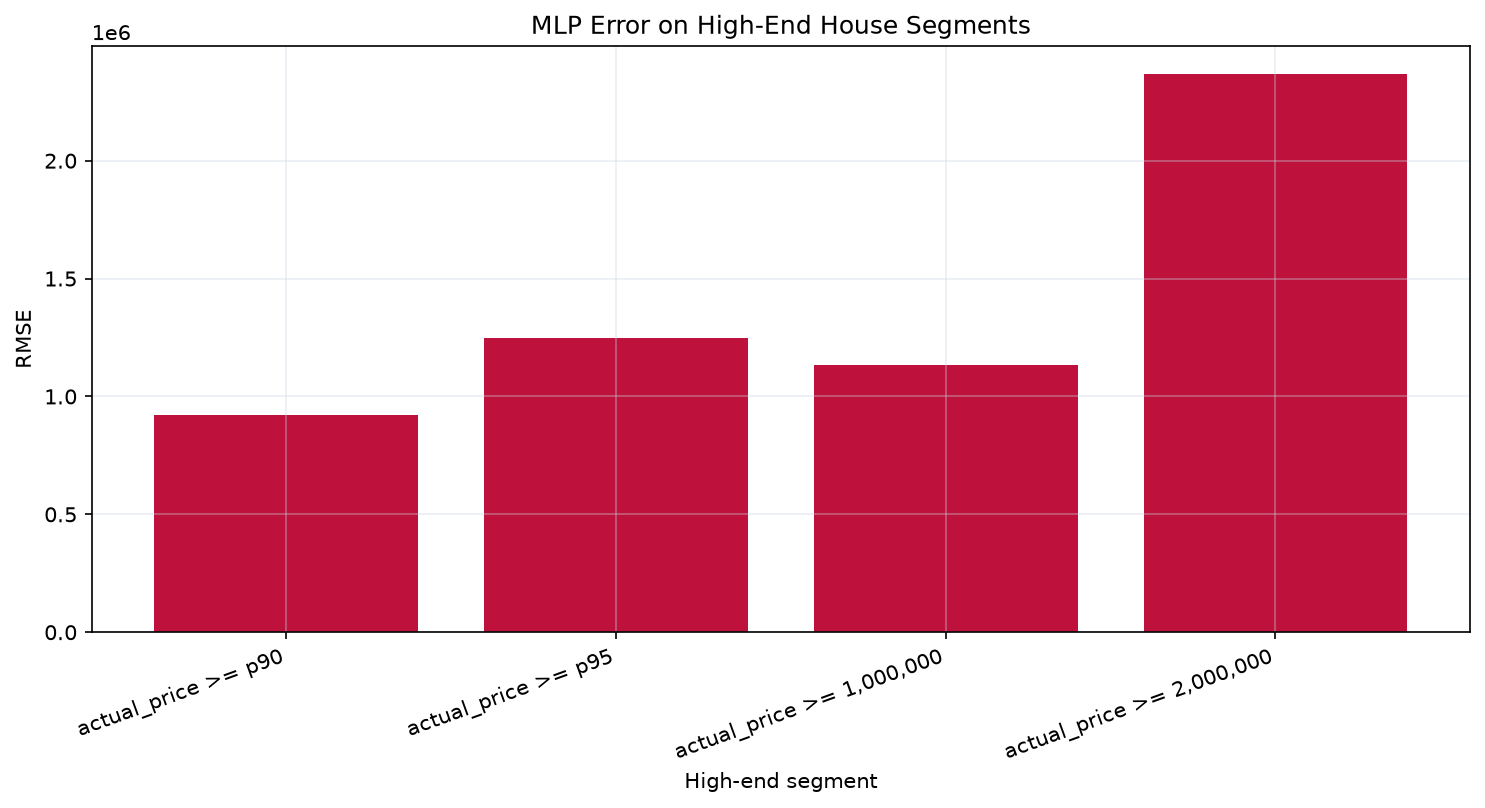

training_validation_loss /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/predictions/training_validation_loss_for_predictions.png


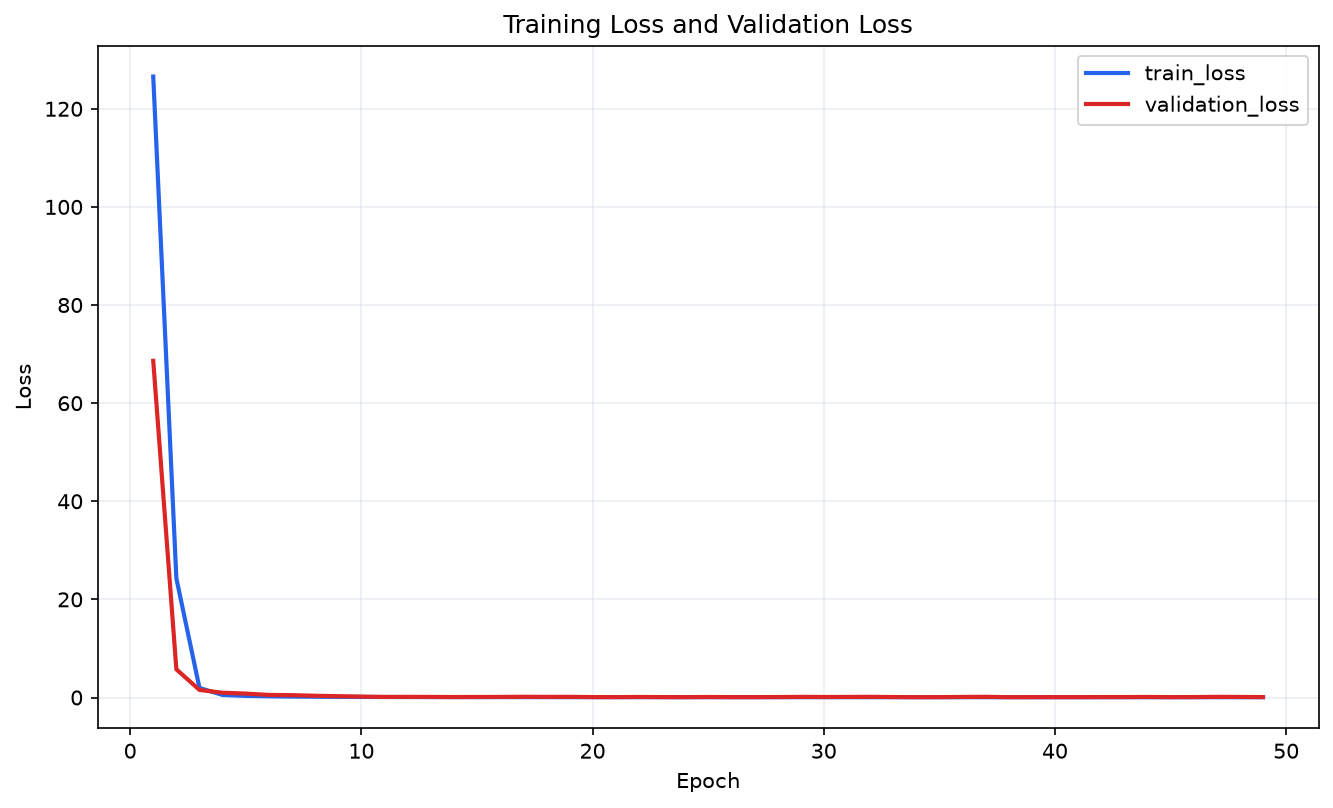

In [19]:
import importlib
import processing_own_phase.phase_19_predictions_visualization as phase_19

phase_19 = importlib.reload(phase_19)
prediction_plot_paths, phase_19_summary = phase_19.run_phase_19_predictions_visualization(
    predictions_df,
    config,
    training_log,
)
phase_19.display_phase_19_summary(phase_19_summary)
display_path_collection(prediction_plot_paths)


## Phase 20 - Build and Train Comparison Models bằng scikit-learn


In [20]:
import importlib
import processing_own_phase.phase_20_comparison_models as phase_20

phase_20 = importlib.reload(phase_20)
comparison_df, fitted_baseline_models, phase_20_summary = phase_20.run_phase_20_comparison_models(
    X_train_processed,
    y_train,
    X_test_processed,
    y_test,
    config,
    inverse_transform,
)
phase_20.display_phase_20_summary(phase_20_summary)
display_path_collection({"baseline_model_metrics": config.results_dir / "baseline_model_metrics.csv"})


### Baseline model results

,rmse_rank,model,MAE,MSE,RMSE,R2,training_time_seconds,inference_time_seconds,target_scale
0,1,Linear Regression,89213.433,81671669837.735,285782.557,0.623,0.031,0.000,original price scale after inverse transform
1,2,Random Forest Regression,84689.223,85224521002.961,291932.391,0.606,2.794,0.026,original price scale after inverse transform
2,3,Decision Tree Regression,115178.294,107567190499.338,327974.375,0.503,0.159,0.000,original price scale after inverse transform


### Fair comparison rules

,rule,phase_20_action,reason
0,Same split,Use the same training and testing sets as MLP,Avoid comparing models on different data
1,Same preprocessing,Use X_train_processed and X_test_processed from Phase 7,"Keep imputation, encoding and scaling consistent"
2,Same target transform,"Train on the same y scale as the MLP, then inverse-transform for reporting",Metrics should be comparable on original price scale
3,Same metrics,"Report MAE, MSE, RMSE, R2, training time and inference time",Compare both accuracy and cost


### Model descriptions

,model,type,purpose
0,Linear Regression,linear baseline,Check whether simple linear relationships are enough
1,Decision Tree Regression,single nonlinear tree,Capture nonlinear rules but may overfit
2,Random Forest Regression,ensemble tree baseline,Stronger nonlinear baseline with reduced variance


baseline_model_metrics /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/baseline_model_metrics.csv


## Phase 21 - Compare All Models


### Model comparison table

,model,MAE,MSE,RMSE,R2,training_time_seconds,inference_time_seconds,target_scale
0,Linear Regression,89213.433,81671669837.735,285782.557,0.623,0.031,0.000,original price scale after inverse transform
1,Decision Tree Regression,115178.294,107567190499.338,327974.375,0.503,0.159,0.000,original price scale after inverse transform
2,Random Forest Regression,84689.223,85224521002.961,291932.391,0.606,2.794,0.026,original price scale after inverse transform
3,MLP Regression PyTorch,99151.514,93745115448.490,306178.241,0.567,5.243,0.006,original price scale after expm1 inverse transform


### Ranked models

,overall_accuracy_rank,model,MAE,MSE,RMSE,R2,training_time_seconds,inference_time_seconds,target_scale,mae_rank,rmse_rank,r2_rank,training_time_rank,inference_time_rank,accuracy_rank_score
0,1,Linear Regression,89213.433,81671669837.735,285782.557,0.623,0.031,0.000,original price scale after inverse transform,2.000,1.000,1.000,1.000,2.000,4.000
1,2,Random Forest Regression,84689.223,85224521002.961,291932.391,0.606,2.794,0.026,original price scale after inverse transform,1.000,2.000,2.000,3.000,4.000,5.000
2,3,MLP Regression PyTorch,99151.514,93745115448.490,306178.241,0.567,5.243,0.006,original price scale after expm1 inverse transform,3.000,3.000,3.000,4.000,3.000,9.000
3,4,Decision Tree Regression,115178.294,107567190499.338,327974.375,0.503,0.159,0.000,original price scale after inverse transform,4.000,4.000,4.000,2.000,1.000,12.000


### Best models by metric

,metric,best_model,best_value,preference,meaning
0,MAE,Random Forest Regression,84689.223,lower,Lower is better; average absolute error
1,MSE,Linear Regression,81671669837.735,lower,Lower is better; squared error penalizes large mistakes
2,RMSE,Linear Regression,285782.557,lower,Lower is better; same unit as price
3,R2,Linear Regression,0.623,higher,Higher is better; explained target variation
4,training_time_seconds,Linear Regression,0.031,lower,Lower is faster to train
5,inference_time_seconds,Decision Tree Regression,0.000,lower,Lower is faster to predict


### Fair comparison rules

,rule,phase_21_check
0,Same test set,MLP and baselines are evaluated on the same testing split
1,Same preprocessing,All models use processed features from the same Phase 7 pipeline
2,Same metrics,"MAE, MSE, RMSE and R2 are compared for every model"
3,Same reporting scale,Metrics should be on original price scale after inverse transform
4,Accuracy and cost,Training time and inference time are kept beside prediction metrics


rmse_by_model /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/comparison/model_comparison_rmse.png


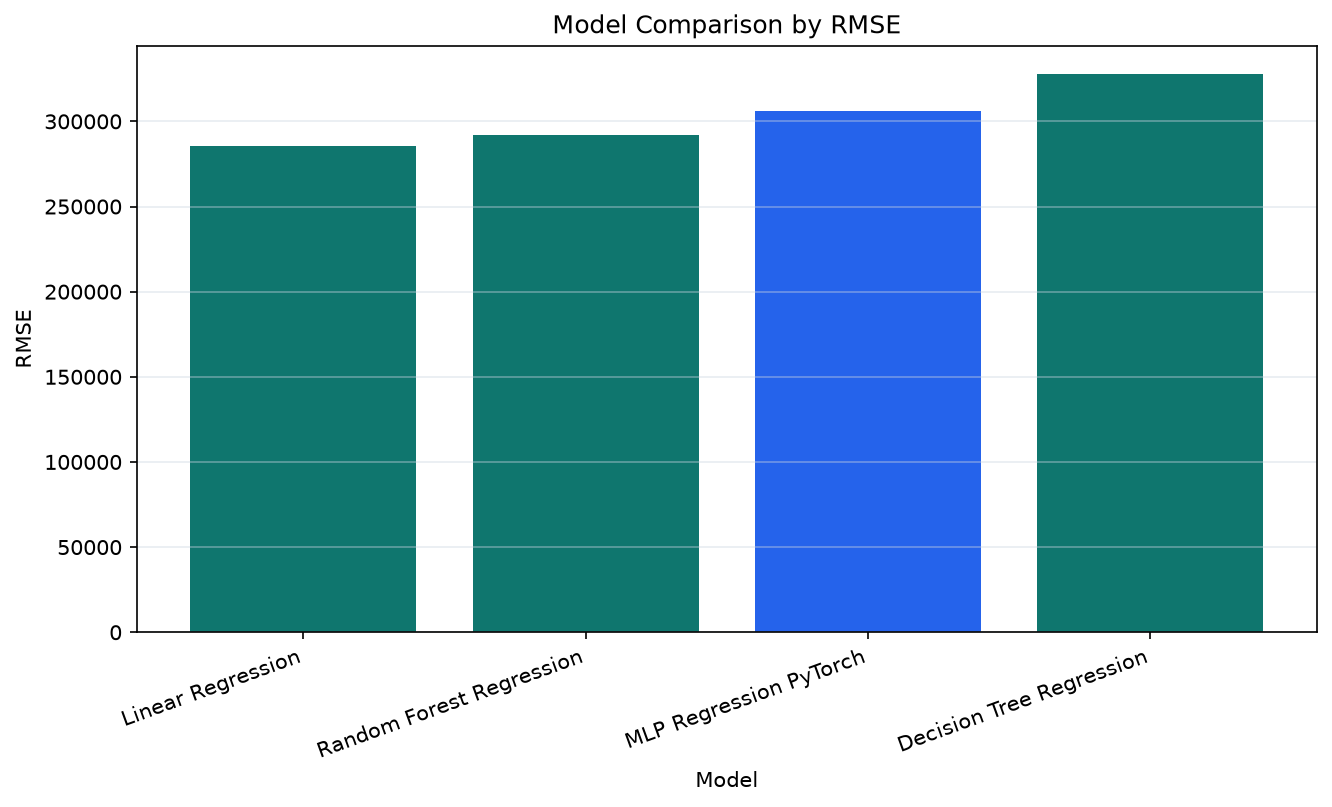

r2_by_model /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/comparison/model_comparison_r2.png


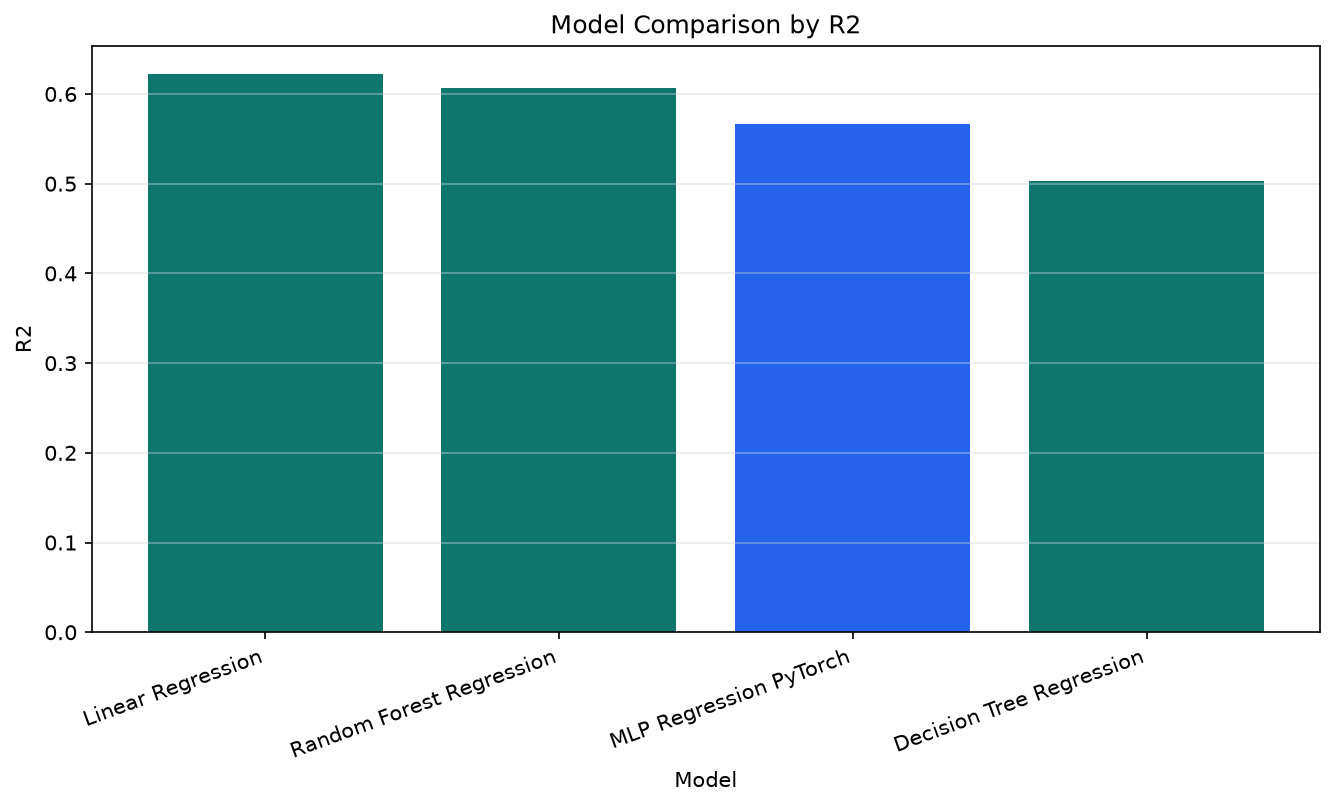

mae_by_model /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/comparison/model_comparison_mae.png


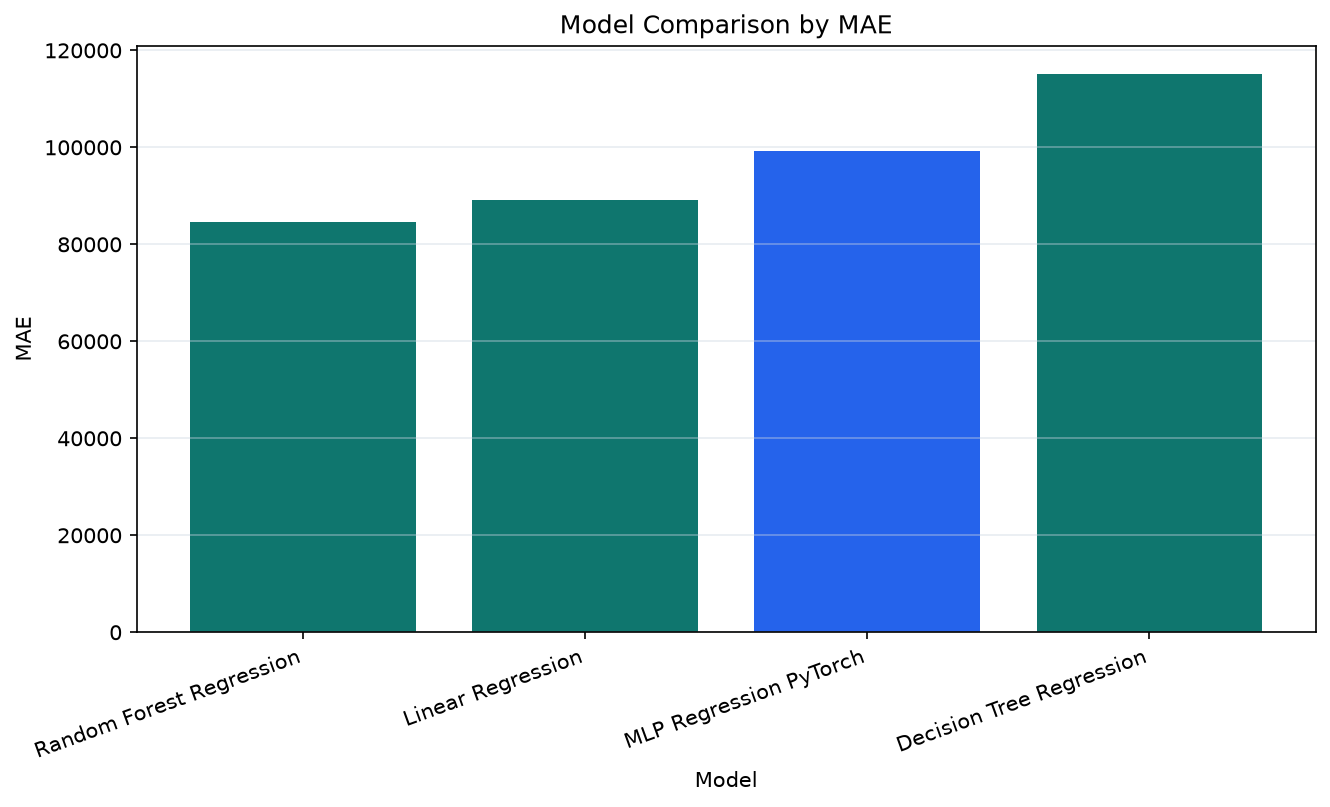

training_time_by_model /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/comparison/model_comparison_training_time_seconds.png


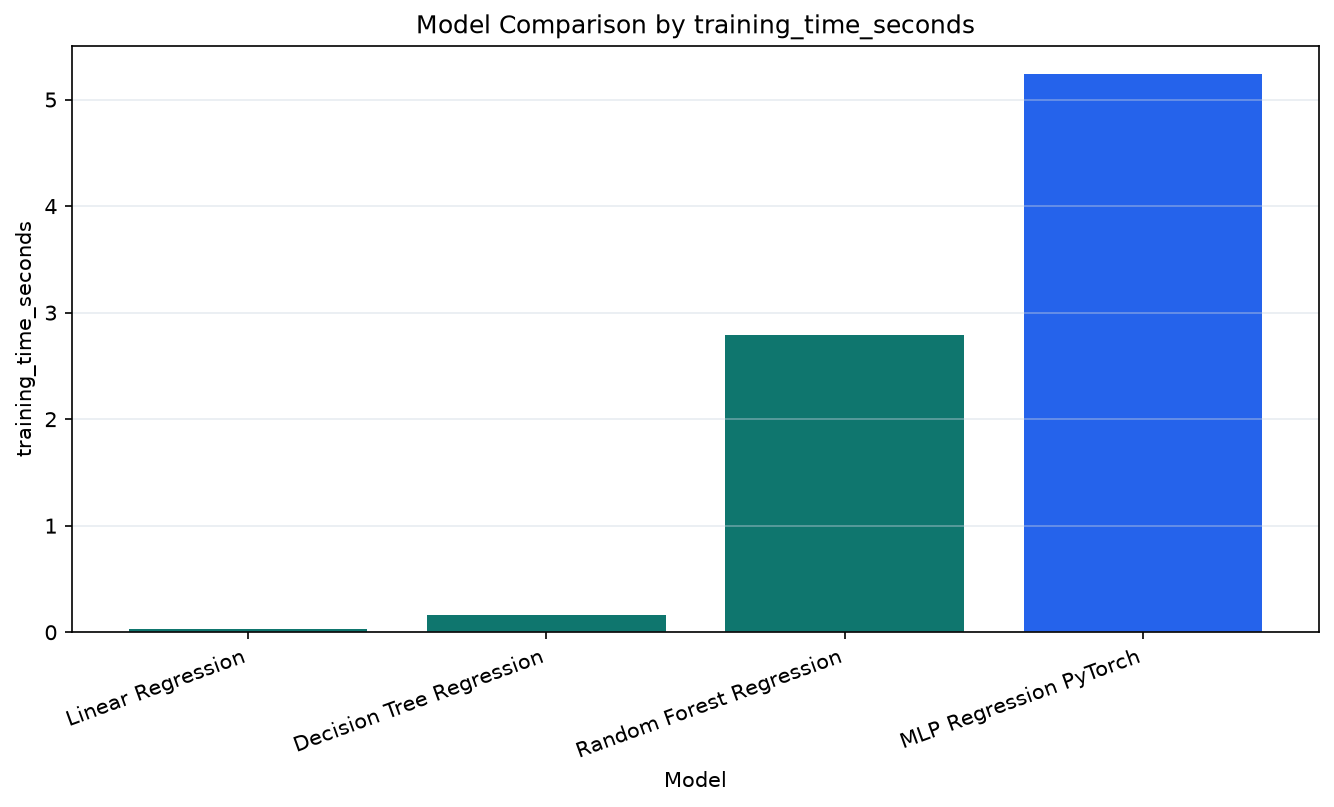

inference_time_by_model /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/comparison/model_comparison_inference_time_seconds.png


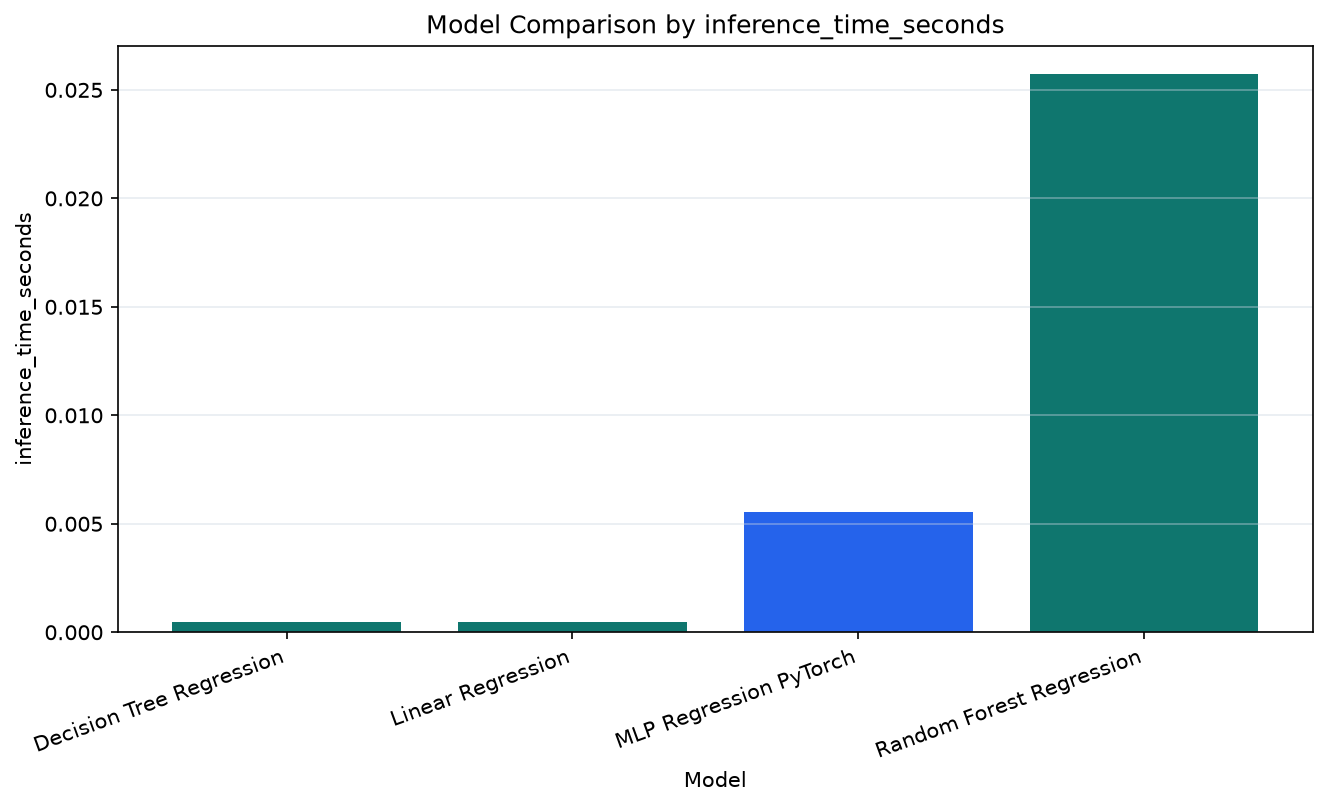

model_comparison /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/model_comparison.csv


In [21]:
import importlib
import processing_own_phase.phase_21_compare_all_models as phase_21

phase_21 = importlib.reload(phase_21)
model_comparison_df, comparison_plot_paths, phase_21_summary = phase_21.run_phase_21_compare_all_models(
    mlp_metrics_df,
    comparison_df,
    config,
)
phase_21.display_phase_21_summary(phase_21_summary)
display_path_collection(comparison_plot_paths)
display_path_collection({"model_comparison": config.comparison_path})


## Phase 22 - Analyze Results


In [22]:
import importlib
import processing_own_phase.phase_22_analyze_results as phase_22

phase_22 = importlib.reload(phase_22)
analysis, phase_22_summary, phase_22_output_paths = phase_22.run_phase_22_analyze_results(
    model_comparison_df,
    training_log,
    config,
)
phase_22.display_phase_22_summary(phase_22_summary)
display_path_collection(phase_22_output_paths)


### Phase 22 question answers

,question,answer,evidence
0,Which model has the lowest MAE?,Random Forest Regression,"MAE = 84,689.223"
1,Which model has the lowest RMSE?,Linear Regression,"RMSE = 285,782.557"
2,Which model has the highest R2?,Linear Regression,R2 = 0.623
3,Is MLP better than the baselines?,MLP is not the best by RMSE; Linear Regression has lower RMSE on the test set.,"Compare MLP rank against Linear Regression, Decision Tree and Random Forest."
4,Is there an overfitting signal?,potential overfitting,Validation loss is much higher than train loss.
5,Which model trains fastest?,Linear Regression,Training time = 0.030860 seconds
6,Which model predicts fastest?,Decision Tree Regression,Inference time = 0.000453 seconds
7,Which model is most suitable overall?,Linear Regression,"Linear Regression has the lowest RMSE, so it makes fewer large errors on the test set. Final selection should still consider inference time and interpretability."


### Metric ranking

,model,MAE,MSE,RMSE,R2,training_time_seconds,inference_time_seconds,target_scale,mae_rank,rmse_rank,r2_rank,accuracy_score
0,Linear Regression,89213.433,81671669837.735,285782.557,0.623,0.031,0.000,original price scale after inverse transform,2.000,1.000,1.000,4.000
1,Random Forest Regression,84689.223,85224521002.961,291932.391,0.606,2.794,0.026,original price scale after inverse transform,1.000,2.000,2.000,5.000
2,MLP Regression PyTorch,99151.514,93745115448.490,306178.241,0.567,5.243,0.006,original price scale after expm1 inverse transform,3.000,3.000,3.000,9.000
3,Decision Tree Regression,115178.294,107567190499.338,327974.375,0.503,0.159,0.000,original price scale after inverse transform,4.000,4.000,4.000,12.000


### Overfitting analysis

,status,final_train_loss,final_validation_loss,final_loss_gap,relative_gap,best_epoch,best_validation_loss,note
0,potential overfitting,0.060,0.087,0.027,0.457,34,0.068,Validation loss is much higher than train loss.


### Final recommendation

,recommended_model,primary_reason,best_rmse,best_r2_model,best_r2
0,Linear Regression,"Linear Regression has the lowest RMSE, so it makes fewer large errors on the test set. Final selection should still consider inference time and interpretability.",285782.557,Linear Regression,0.623


analysis_summary /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/analysis_summary.json
analysis_question_answers /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/analysis_question_answers.csv


## Phase 23 - Model Interpretation


### Top Random Forest feature importance

,feature,importance
0,numerical__grade,0.321
1,numerical__lat,0.283
2,numerical__sqft_living,0.167
3,numerical__long,0.047
4,numerical__sqft_living15,0.027
5,numerical__sqft_above,0.016
6,numerical__house_age,0.014
7,numerical__sqft_lot15,0.013
8,numerical__sqft_lot,0.011
9,numerical__yr_built,0.011


### Residual summary

,mean_residual,median_residual,std_residual,mean_absolute_error,median_absolute_error,max_absolute_error,mean_absolute_percentage_error
0,27922.962,14419.999,304972.306,99151.514,48019.871,7858404.489,97.661


### Error by price segment

,price_segment,samples,mean_actual_price,mean_predicted_price,mean_residual,mean_absolute_error,mean_absolute_percentage_error
0,"(999.999, 299980.001]",436,233875.085,253392.247,-19517.162,43435.245,429.006
1,"(299980.001, 397500.076]",437,345198.656,350491.801,-5293.145,43956.493,12.744
2,"(397500.076, 519939.892]",434,450532.251,447269.441,3262.810,54005.762,12.030
3,"(519939.892, 700000.327]",447,603471.246,573859.934,29611.312,89304.966,14.774
4,"(700000.327, 8611111.114]",425,1135219.828,1001068.283,134151.545,269521.351,19.678


### Interpretation notes

,topic,note
0,Why Random Forest importance,"MLP is harder to interpret directly, so Random Forest gives a useful feature-importance reference."
1,Residual mean,Positive mean residual means predictions are lower than actual prices on average.
2,Error by segment,Higher error in expensive segments means the model struggles more with high-value homes.
3,Important caution,"Feature importance from Random Forest explains the baseline model, not the exact inner logic of the MLP."


random_forest_feature_importance_csv /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/random_forest_feature_importance.csv
random_forest_feature_importance_plot /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots/comparison/random_forest_feature_importance.png


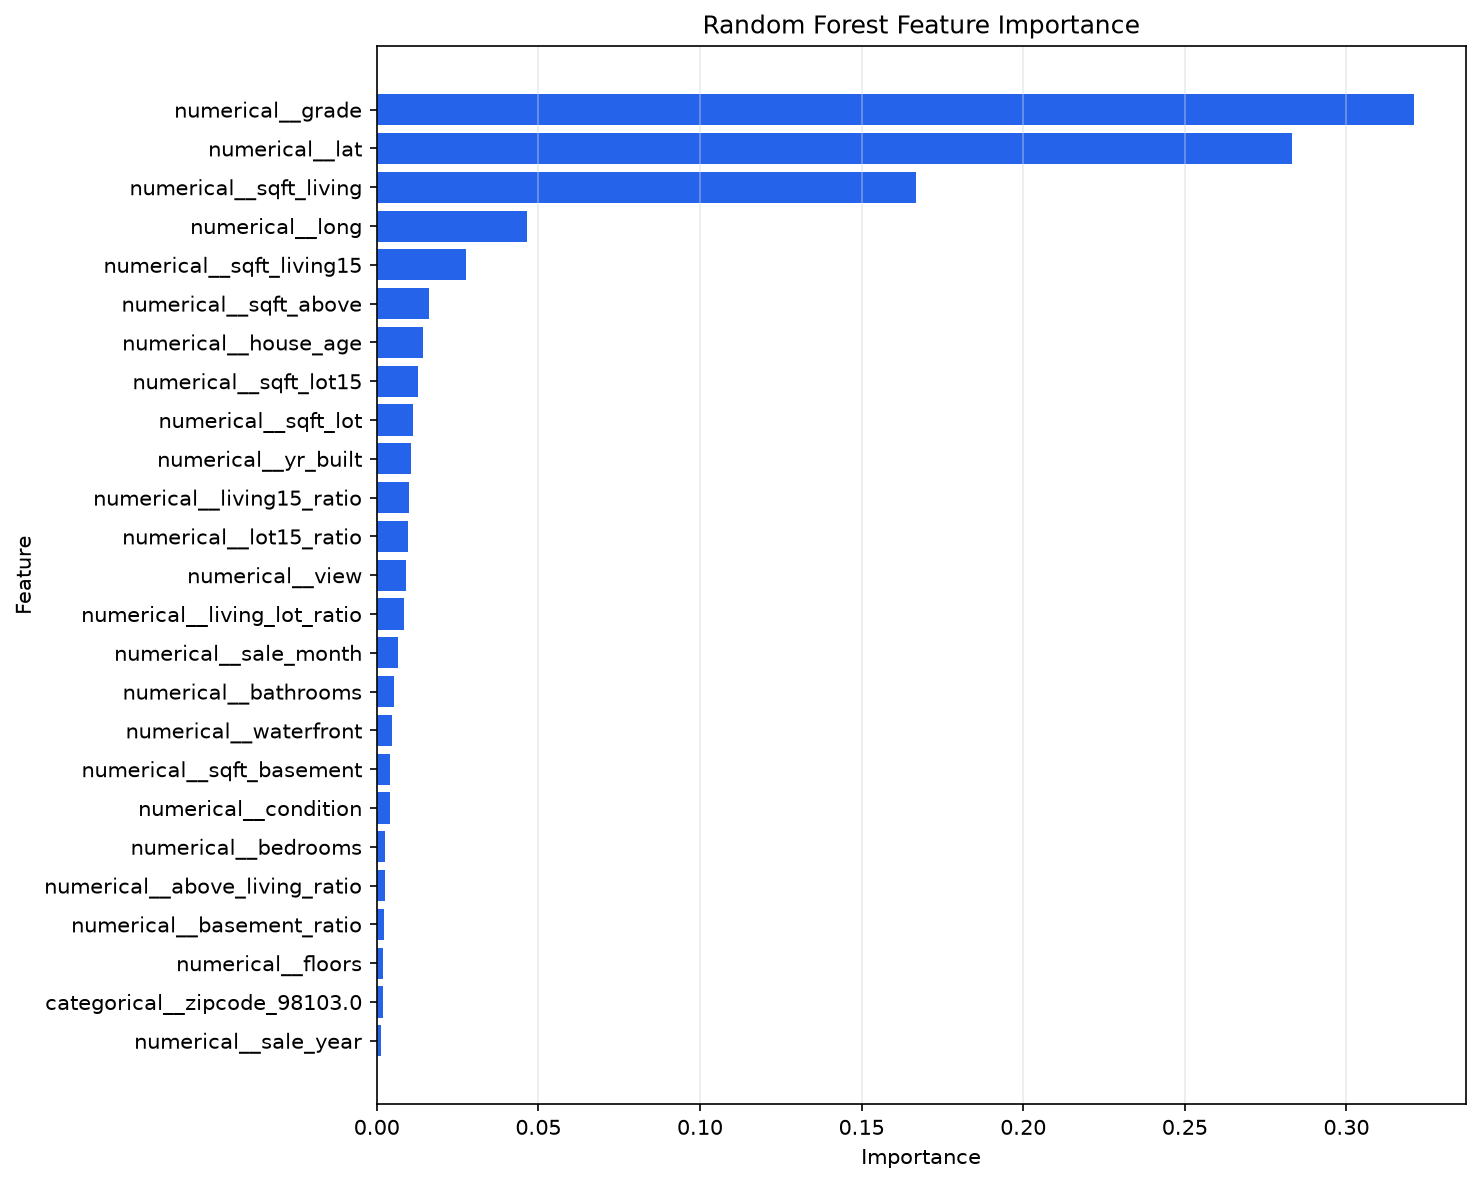

residual_summary /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/residual_summary.csv
error_by_price_segment /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/error_by_price_segment.csv


In [23]:
import importlib
import processing_own_phase.phase_23_model_interpretation as phase_23

phase_23 = importlib.reload(phase_23)
rf_importance_df, residual_summary_df, phase_23_summary, phase_23_output_paths = phase_23.run_phase_23_model_interpretation(
    fitted_baseline_models,
    feature_names,
    predictions_df,
    config,
)
phase_23.display_phase_23_summary(phase_23_summary)
display_path_collection(phase_23_output_paths)


## Phase 24 - Save Artifacts


In [24]:
import importlib
import processing_own_phase.phase_24_save_artifacts as phase_24

phase_24 = importlib.reload(phase_24)
artifact_paths, phase_24_summary = phase_24.run_phase_24_save_artifacts(
    model,
    preprocessor,
    model_comparison_df,
    predictions_df,
    config,
    analysis,
)
phase_24.display_phase_24_summary(phase_24_summary)
display_path_collection(artifact_paths)


### Artifact manifest

,artifact,path,exists,purpose
0,best_mlp_model,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/best_mlp_model.pth,True,Best/restored PyTorch MLP model weights
1,preprocess_pipeline,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/preprocess_pipeline.joblib,True,Fitted sklearn preprocessing pipeline
2,config,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/config.json,True,Project configuration and hyperparameters
3,model_comparison,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/model_comparison.csv,True,Metrics for MLP and baseline models
4,mlp_predictions,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/mlp_predictions.csv,True,Actual and predicted house prices for the test set
5,training_log,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/logs/training_log.csv,True,Epoch-level PyTorch training log
6,analysis_summary,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/analysis_summary.json,True,Phase 22 final analysis summary
7,plots_dir,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots,True,All generated plots grouped by phase
8,artifact_manifest,/Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/artifact_manifest.csv,True,Project output artifact


### Missing artifact check

,artifact,path,exists,purpose
0,-,-,True,All artifacts exist


best_mlp_model /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/best_mlp_model.pth
preprocess_pipeline /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/preprocess_pipeline.joblib
config /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/artifacts/config.json
model_comparison /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/model_comparison.csv
mlp_predictions /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/mlp_predictions.csv
training_log /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/logs/training_log.csv
analysis_summary /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/analysis_summary.json
plots_dir /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/plots
artifact_manifest /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/artifact_manifest

## Phase 25 - Final Conclusion


In [25]:
import importlib
import processing_own_phase.phase_25_final_conclusion as phase_25

phase_25 = importlib.reload(phase_25)
final_conclusion, phase_25_summary, phase_25_output_paths = phase_25.run_phase_25_final_conclusion(
    model_comparison_df,
    analysis,
    config,
)
phase_25.display_phase_25_summary(phase_25_summary, final_conclusion)
display_path_collection(phase_25_output_paths)


### Final conclusion

Dự án đã xây dựng pipeline dự đoán giá nhà bằng MLP Regression với PyTorch, trong đó dữ liệu được chia 80/10/10 và toàn bộ preprocessing được fit trên training set để tránh data leakage. Sau khi đánh giá trên test set, model có RMSE tốt nhất là Linear Regression, model có R2 tốt nhất là Linear Regression. Nhận xét MLP so với baseline: MLP is not the best by RMSE; Linear Regression has lower RMSE on the test set. Tín hiệu overfitting hiện tại: potential overfitting. Model được đề xuất cho kết quả hiện tại là Linear Regression, nhưng lựa chọn cuối nên cân bằng giữa accuracy, inference speed và interpretability.

### Project summary

,stage,summary
0,Data split,Raw data split into train/validation/test with 80/10/10 ratio
1,Preprocessing,"Missing imputation, encoding and scaling handled with sklearn pipeline"
2,Modeling,MLP Regression implemented with PyTorch
3,Monitoring,"Training log, validation metrics, gradient norm and early stopping tracked"
4,Evaluation,MLP evaluated on test set and compared with sklearn baselines
5,Artifacts,"Model, pipeline, metrics, predictions, plots and config saved to output/"


### Key results

...

### Limitations

,limitation,note
0,MLP interpretability,MLP is harder to explain directly than tree or linear baselines.
1,Hyperparameter search,Phase 17 uses a controlled small grid unless expanded manually.
2,Feature importance,"Random Forest feature importance is a reference, not the exact MLP decision logic."
3,Final metric reliability,Conclusion depends on running enough epochs and using the best restored model.


### Next steps

,next_step,reason
0,Run full notebook,Confirm all outputs are generated in the same kernel
1,Tune hyperparameters,Improve MLP performance beyond the default config
2,Inspect high-error cases,Understand where the model struggles most
3,Try more features,Location and interaction features may improve price prediction
4,Compare deployment tradeoffs,"Balance accuracy, inference speed and interpretability"


final_conclusion /Users/vientu/MACHINE LEARNING/Multilayer Perceptron Regression/output/results/final_conclusion.md
